**Запуск jupyter-notebook**

In [ ]:
#python -m notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=8888 --NotebookApp.port_retries=0 --NotebookApp.allow_credentials=True

**Необходимые библиотеки**

In [ ]:
!pip -q install openai requests pandas tqdm scikit-learn matplotlib tabulate

**Импорты**

In [1]:
from __future__ import annotations

import shutil

import json
import os
import random
import re
import time
from pathlib import Path
from typing import Any, Optional

import matplotlib.pyplot as plt
import pandas as pd
import requests
from openai import OpenAI
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

**Параметры экспериментов**

In [2]:
ABLATION_SAMPLES_PER_TOPIC_LABEL = 20
N_GENERATION_PER_TOPIC_STANCE = 20
EVAL_SAMPLES_PER_TOPIC_LABEL = 50

In [3]:
SEED = 42
random.seed(SEED)

OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")

if not OPENROUTER_API_KEY:
    try:
        from getpass import getpass
        os.environ["OPENROUTER_API_KEY"] = getpass("Введите OpenRouter API key: ")
        OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
    except Exception:
        OPENROUTER_API_KEY = None

if not OPENROUTER_API_KEY:
    raise RuntimeError(
        "Не задан OPENROUTER_API_KEY. Установи переменную окружения перед запуском: "
        "os.environ['OPENROUTER_API_KEY'] = 'sk-or-...'"
    )

client = OpenAI(
    base_url=OPENROUTER_BASE_URL,
    api_key=OPENROUTER_API_KEY,
    default_headers={
        # Эти заголовки опциональны. Они помогают OpenRouter атрибутировать приложение.
        "HTTP-Referer": "https://github.com/kz-gameowner/vkr-llm-arguments",
        "X-OpenRouter-Title": "VK R RuArg cloud experiment",
    },
)

# Отдельная папка нужна, чтобы не смешивать локальные и облачные результаты.
RESULTS_DIR = Path("results_vkr_openrouter_experiment")
RESULTS_DIR.mkdir(exist_ok=True)

CLASSIFICATION_DIR = RESULTS_DIR / "classification"
GENERATION_DIR = RESULTS_DIR / "generation"
ABLATION_DIR = CLASSIFICATION_DIR / "ablation_experiments"

# Judge-этап сознательно не запускается в этом ноутбуке.
# Отдельный judge-ноутбук можно будет подключить позже к generated_arguments.csv.
JUDGE_DIR = RESULTS_DIR / "judge_not_used"

for folder in [CLASSIFICATION_DIR, GENERATION_DIR, ABLATION_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Backend: OpenRouter")
print("Папка результатов:", RESULTS_DIR.resolve())


Введите OpenRouter API key: ··········
Backend: OpenRouter
Папка результатов: C:\Windows\System32\results_vkr_openrouter_experiment


**Очистка кэша перед запуском эксперимента**

Если необходимо

In [4]:
def delete_paths(paths: list[Path], dry_run: bool = True) -> None:
    for path in paths:
        if path.exists():
            if dry_run:
                print("[DRY RUN] Удалил бы:", path)
            else:
                print("Удаляю:", path)
                path.unlink()

In [5]:
def clean_ablation_cache_and_outputs(dry_run: bool = True) -> None:
    if "ABLATION_DIR" not in globals():
        print("ABLATION_DIR не определен.")
        return

    patterns = [
        "cache_*.json",
        "predictions_*.csv",
        "metrics_*.json",
        "*summary*.csv",
        "*status*.csv",
        "*.png",
    ]

    paths = []
    for pattern in patterns:
        paths.extend(ABLATION_DIR.glob(pattern))

    delete_paths(paths, dry_run=dry_run)

In [6]:
def clean_generation_outputs(dry_run: bool = True) -> None:
    patterns = [
        "generation_tasks.csv",
        "generated_arguments.csv",
        "generation_run_status.csv",
        "generation_artifact_summary.csv",
        "*.png",
    ]

    paths = []
    for pattern in patterns:
        paths.extend(GENERATION_DIR.glob(pattern))

    delete_paths(paths, dry_run=dry_run)

In [7]:
def clean_judge_outputs(dry_run: bool = True) -> None:
    patterns = [
        "judged_arguments.csv",
        "generation_summary_by_model.csv",
        "generation_summary_by_topic.csv",
        "generation_summary_by_stance.csv",
        "*.png",
    ]

    paths = []
    for pattern in patterns:
        paths.extend(JUDGE_DIR.glob(pattern))

    delete_paths(paths, dry_run=dry_run)

In [8]:
def clean_all_experiment_outputs(dry_run: bool = True) -> None:
    clean_classification_cache_and_outputs(dry_run=dry_run)
    clean_ablation_cache_and_outputs(dry_run=dry_run)
    clean_generation_outputs(dry_run=dry_run)
    clean_judge_outputs(dry_run=dry_run)

In [9]:
def clean_classification_cache_and_outputs(dry_run: bool = True) -> None:
    patterns = [
        "cache_*.json",
        "predictions_*.csv",
        "metrics_*.json",
        "classification_summary*.csv",
        "classification_run_status*.csv",
        "confusion_matrix_*.png",
        "classification_summary*.png",
        "classification_topic_f1*.png",
    ]

    paths = []
    for pattern in patterns:
        paths.extend(CLASSIFICATION_DIR.glob(pattern))

    delete_paths(paths, dry_run=dry_run)

In [10]:
clean_classification_cache_and_outputs(dry_run=True)
clean_ablation_cache_and_outputs(dry_run=True)

In [11]:
clean_classification_cache_and_outputs(dry_run=False)
clean_ablation_cache_and_outputs(dry_run=False)

# **Эксперимент**

**Backend OpenRouter**

In [12]:
USE_AUTO_LOAD_UNLOAD = False

def load_lmstudio_model(*args, **kwargs):
    """Заглушка для совместимости с локальной версией ноутбука."""
    print("OpenRouter backend: ручная загрузка моделей не требуется.")
    return None


def unload_lmstudio_model(*args, **kwargs) -> bool:
    """Заглушка для совместимости с локальной версией ноутбука."""
    return True


def unload_all_llms() -> None:
    """Заглушка для совместимости с локальной версией ноутбука."""
    return None


**Список облачных моделей**

Ниже задаётся единый список моделей OpenRouter - список используется во всех трёх этапах: ablation, основной классификации и генерации аргументов.

In [13]:
OPENROUTER_MODEL_RUNS = [
    {
        "alias": "or_qwen35_plus_20260420",
        "model_id": "qwen/qwen3.5-plus-20260420",
    },
    {
        "alias": "or_qwen35_122b_a10b",
        "model_id": "qwen/qwen3.5-122b-a10b",
    },
    {
        "alias": "or_kimi_k26",
        "model_id": "moonshotai/kimi-k2.6",
    },
    {
        "alias": "or_deepseek_v4_pro",
        "model_id": "deepseek/deepseek-v4-pro",
    },
    {
        "alias": "or_gemma4_26b_a4b",
        "model_id": "google/gemma-4-26b-a4b-it",
    },
]

MODEL_RUNS = OPENROUTER_MODEL_RUNS.copy()

pd.DataFrame(MODEL_RUNS)


,alias,model_id
0,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420
1,or_qwen35_122b_a10b,qwen/qwen3.5-122b-a10b
2,or_kimi_k26,moonshotai/kimi-k2.6
3,or_deepseek_v4_pro,deepseek/deepseek-v4-pro
4,or_gemma4_26b_a4b,google/gemma-4-26b-a4b-it


In [14]:
TRAIN_URL = "https://raw.githubusercontent.com/dialogue-evaluation/RuArg/main/data/train.tsv"

TOPIC2THESIS = {
    "masks": "Ношение масок полезно для общества.",
    "quarantine": "Введение и соблюдение карантина полезно для общества.",
    "vaccines": "Вакцинация полезна для общества.",
}

LABEL_ID2NAME = {
    0: "AGAINST",
    1: "NO_ARG",
    2: "FOR",
}

LABEL_NAME2ID = {v: k for k, v in LABEL_ID2NAME.items()}

FEWSHOT_PER_LABEL = 1
REQUEST_PAUSE_SECONDS = 0.6  # техническая пауза между облачными API-запросами

In [15]:
def load_ruarg_train(url: str = TRAIN_URL) -> pd.DataFrame:
    df = pd.read_csv(url, sep="\t")

    required_cols = {
        "text_id",
        "text",
        "masks_argument",
        "quarantine_argument",
        "vaccines_argument",
    }

    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"В train.tsv не хватает колонок: {sorted(missing)}")

    return df

In [16]:
def build_argument_examples(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for topic, thesis in TOPIC2THESIS.items():
        arg_col = f"{topic}_argument"

        part = df.loc[df[arg_col] != -1, ["text_id", "text", arg_col]].copy()
        part["topic"] = topic
        part["thesis"] = thesis
        part["label"] = part[arg_col].astype(int)
        part = part.drop(columns=[arg_col])

        rows.append(part)

    out = pd.concat(rows, ignore_index=True)

    out["text"] = out["text"].astype(str).str.strip()
    out = out[out["text"] != ""].copy()

    out["stratify_key"] = (
        out["topic"].astype(str) + "__" + out["label"].astype(str)
    )

    return out

In [17]:
def split_train_eval(examples: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Финальный вариант разбиения:
    1) сначала формирует сбалансированный eval по topic-label;
    2) все остальные примеры оставляет в train;
    3) если в группе меньше EVAL_SAMPLES_PER_TOPIC_LABEL, берет сколько есть.
    """

    eval_indices = []

    for (topic, label), group in examples.groupby(["topic", "label"]):
        n = min(len(group), EVAL_SAMPLES_PER_TOPIC_LABEL)

        picked = group.sample(
            n=n,
            random_state=SEED,
        )

        eval_indices.extend(picked.index.tolist())

    eval_df = examples.loc[eval_indices].copy()
    train_df = examples.drop(index=eval_indices).copy()

    eval_df = eval_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

    return train_df, eval_df

In [18]:
raw_df = load_ruarg_train()
examples = build_argument_examples(raw_df)
train_df, eval_df = split_train_eval(examples)

In [19]:
print("Размер исходного корпуса:", raw_df.shape)
print("Размер преобразованного корпуса:", examples.shape)
print("Train size:", len(train_df))
print("Eval size:", len(eval_df))

Размер исходного корпуса: (6717, 8)
Размер преобразованного корпуса: (6888, 6)
Train size: 6438
Eval size: 450


In [20]:
display(examples.head())

,text_id,text,topic,thesis,label,stratify_key
0,17037,"[USER], почему доктор зойдберг не имеет песню ...",masks,Ношение масок полезно для общества.,1,masks__1
1,17042,"вот из-за таких идиотов, которые ходят без мас...",masks,Ношение масок полезно для общества.,1,masks__1
2,17197,"У кого-то все прилежно на карантине сидят, мас...",masks,Ношение масок полезно для общества.,1,masks__1
3,17336,"[USER], наших людей если не напугать, то они н...",masks,Ношение масок полезно для общества.,1,masks__1
4,17375,"[USER], Потому что те, кто сейчас занёс ковид1...",masks,Ношение масок полезно для общества.,1,masks__1


In [21]:
display(examples.tail())

,text_id,text,topic,thesis,label,stratify_key
6883,34033,"[USER], меня больше заботят врачи, которые вын...",vaccines,Вакцинация полезна для общества.,1,vaccines__1
6884,34034,жрёт и жрёт вирус народ когда вакцина к нам пр...,vaccines,Вакцинация полезна для общества.,1,vaccines__1
6885,34035,"Меня другой вопрос волнует, что ещё убьёт эта ...",vaccines,Вакцинация полезна для общества.,1,vaccines__1
6886,34037,"А потом будут говорить про ""российскую медицин...",vaccines,Вакцинация полезна для общества.,1,vaccines__1
6887,34039,"Вакцина не предотвращает заболевание, она прос...",vaccines,Вакцинация полезна для общества.,2,vaccines__2


In [22]:
display(
    eval_df
    .assign(label_name=eval_df["label"].map(LABEL_ID2NAME))
    .groupby(["topic", "label_name"])
    .size()
    .unstack(fill_value=0)
)

label_name,AGAINST,FOR,NO_ARG
topic,,,
masks,50,50,50
quarantine,50,50,50
vaccines,50,50,50


In [23]:
PROMPT_MODES = {
    "zero_shot": {
        "description": "Модель получает только инструкцию, тезис и текст без размеченных примеров.",
        "use_fewshot": False,
    },
    "few_shot": {
        "description": "Модель получает инструкцию, тезис, текст и few-shot примеры.",
        "use_fewshot": True,
    },
}

In [24]:
SYSTEM_PROMPT_CLASSIFICATION = """Ты выполняешь классификацию аргументов в русскоязычных текстах.

/no_think

Нужно определить отношение текста к заданному тезису.

Классы:
0 = AGAINST: текст содержит аргумент против тезиса;
1 = NO_ARG: текст не содержит явного аргумента по тезису;
2 = FOR: текст содержит аргумент в поддержку тезиса.

Правила:
1) учитывай связь текста именно с заданным тезисом;
2) аргументом считается высказывание, где есть причина, следствие, пример, объяснение или обоснование;
3) эмоциональная реплика без обоснования — это 1;
4) если текст содержит обоснованную позицию против тезиса — это 0;
5) если текст содержит обоснованную позицию в поддержку тезиса — это 2.

Верни ответ строго в формате:
LABEL_ID=<0 или 1 или 2>

Не добавляй пояснения, рассуждения, markdown или другие слова.
"""

In [25]:
def fewshot_examples(
    train_df: pd.DataFrame,
    topic: str,
    k_per_label: int = FEWSHOT_PER_LABEL,
) -> list[dict[str, Any]]:
    out = []
    topic_df = train_df[train_df["topic"] == topic]

    for label in [2, 0, 1]:  # FOR, AGAINST, NO_ARG
        subset = topic_df[topic_df["label"] == label]

        if subset.empty:
            continue

        picked = subset.sample(
            min(k_per_label, len(subset)),
            random_state=SEED + label,
        )

        out.extend(
            picked[["text", "thesis", "label"]].to_dict("records")
        )

    return out

In [26]:
def build_classification_prompt(row: pd.Series,
    shots: list[dict[str, Any]],
    prompt_mode: str = "few_shot",
) -> str:
    if prompt_mode not in PROMPT_MODES:
        raise ValueError(f"Неизвестный prompt_mode: {prompt_mode}")

    use_fewshot = PROMPT_MODES[prompt_mode]["use_fewshot"]

    parts = [
        "/no_think\n"
        "Классифицируй текст относительно заданного тезиса.\n\n"
        "Классы:\n"
        "0 = AGAINST: текст содержит аргумент против тезиса;\n"
        "1 = NO_ARG: текст не содержит явного аргумента по тезису;\n"
        "2 = FOR: текст содержит аргумент в поддержку тезиса.\n\n"
        "Аргументом считается высказывание, где есть причина, следствие, пример, объяснение или обоснование.\n"
        "Эмоциональная реплика без причины, примера, следствия или объяснения относится к классу 1 = NO_ARG.\n\n"
        "Формат ответа строго такой:\n"
        "LABEL_ID=<0 или 1 или 2>\n"
    ]

    if use_fewshot:
        parts.append("\nНиже приведены примеры разметки.\n")

        for i, ex in enumerate(shots, start=1):
            parts.append(
                f"Пример {i}\n"
                f"Тезис: {ex['thesis']}\n"
                f"Текст: {ex['text']}\n"
                f"Ответ: LABEL_ID={int(ex['label'])}\n"
            )

    parts.append(
        "\nТеперь разметь новый пример.\n"
        f"Тезис: {row['thesis']}\n"
        f"Текст: {row['text']}\n"
        "Ответ:"
    )

    return "\n".join(parts)

In [27]:
def safe_filename(name: str) -> str:
    name = str(name).strip()
    name = re.sub(r"[\\/:\*\?\"<>\|\s]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_")

In [28]:
def resolve_model_id(model_id: Optional[str] = None) -> str:
    if not model_id:
        raise ValueError("Для OpenRouter нужно явно указать model_id в MODEL_RUNS.")

    return model_id


In [29]:
def remove_thinking_blocks(text: str) -> str:
    text = str(text)

    # Удаляем полноценные <think>...</think>
    text = re.sub(
        r"<think>.*?</think>",
        "",
        text,
        flags=re.S | re.I,
    )

    # Если модель начала с <think>, но не закрыла блок,
    # удаляем только сам маркер, чтобы не потерять весь ответ.
    text = re.sub(r"</?think>", "", text, flags=re.I)

    # Удаляем некоторые служебные токены reasoning-моделей
    text = re.sub(r"<\|.*?\|>", "", text)

    return text.strip()

In [30]:
def extract_message_text_from_response(response: Any) -> str:
    msg = response.choices[0].message

    candidates = []

    content = getattr(msg, "content", None)

    if content:
        if isinstance(content, list):
            candidates.append(" ".join(str(x) for x in content))
        else:
            candidates.append(str(content))

    # Некоторые reasoning-модели могут возвращать ответ в нестандартных полях.
    for attr in ["reasoning_content", "reasoning", "thinking", "analysis"]:
        value = getattr(msg, attr, None)
        if value:
            candidates.append(str(value))

    try:
        dump = msg.model_dump()
        for key, value in dump.items():
            if key not in {"role", "content"} and value:
                if isinstance(value, str):
                    candidates.append(value)
    except Exception:
        pass

    text = "\n".join(candidates).strip()
    return text

In [31]:
def chat_complete_model(
    messages: list[dict[str, str]],
    model_id: Optional[str],
    temperature: float = 0.0,
    top_p: float = 1.0,
    max_tokens: int = 64,
    retries: int = 4,
    pause: float = 4.0,
) -> str:
    """Единая функция обращения к облачной модели через OpenRouter.

    Все экспериментальные функции вызывают именно этот слой. Благодаря этому
    classification, ablation и generation остаются сопоставимыми с локальной
    версией: меняется только транспортный backend.
    """
    actual_model_id = resolve_model_id(model_id)
    last_error = None

    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=actual_model_id,
                messages=messages,
                temperature=temperature,
                top_p=top_p,
                max_tokens=max_tokens,
            )

            text = extract_message_text_from_response(response)

            if text:
                text = remove_thinking_blocks(text)
                if text:
                    return text.strip()

            time.sleep(pause)

        except Exception as exc:
            last_error = exc
            print(f"Ошибка OpenRouter-запроса, попытка {attempt + 1}/{retries}: {exc}")
            time.sleep(pause * (attempt + 1))

    if last_error is not None:
        print("Последняя ошибка:", last_error)

    return ""

# Старое имя оставлено как alias, чтобы не ломать отдельные ячейки при переносе.
chat_complete_lmstudio = chat_complete_model


In [32]:
def parse_label(raw: str) -> Optional[int]:
    if raw is None:
        return None

    text = str(raw).upper().strip()
    text = text.replace("-", "_")

    matches = re.findall(r"LABEL_ID\s*[:=]\s*([012])", text)
    if matches:
        return int(matches[-1])

    matches = re.findall(r'"?LABEL_ID"?\s*[:=]\s*"?([012])"?', text)
    if matches:
        return int(matches[-1])

    compact = re.sub(r"\s+", "", text)
    if compact in {"0", "1", "2"}:
        return int(compact)

    label_matches = re.findall(r"\b(NO_ARG|NO_ARGUMENT|AGAINST|FOR)\b", text)

    if label_matches:
        value = label_matches[-1]
        if value in {"NO_ARG", "NO_ARGUMENT"}:
            return 1
        if value == "AGAINST":
            return 0
        if value == "FOR":
            return 2

    if re.search(r"\bНЕТ\s+АРГУМЕНТА\b|\bНЕТ_АРГУМЕНТА\b", text):
        return 1
    if re.search(r"\bПРОТИВ\b", text):
        return 0
    if re.search(r"\bЗА\b", text):
        return 2

    return None

In [33]:
def classify_one(
    row: pd.Series,
    shots: list[dict[str, Any]],
    model_id: str,
    system_prompt: Optional[str] = None,
    prompt_mode: str = "few_shot",
) -> tuple[int, str]:

    if system_prompt is None:
        system_prompt = SYSTEM_PROMPT_CLASSIFICATION

    user_prompt = build_classification_prompt(
        row=row,
        shots=shots,
        prompt_mode=prompt_mode,
    )

    raw = ""
    label = None

    # Основной запрос: несколько попыток, если модель вернула пустой ответ
    for _ in range(3):
        raw = chat_complete_model(
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            model_id=model_id,
            temperature=0.0,
            top_p=1.0,
            max_tokens=64,
        )

        if raw and raw.strip():
            label = parse_label(raw)
            if label is not None:
                return label, raw

        time.sleep(1.0)

    # Repair-запрос, если ответ непустой, но метка не распарсилась
    if raw and raw.strip():
        repair_prompt = f"""
Из ответа модели нужно извлечь итоговую метку классификации.

Классы:
0 = AGAINST
1 = NO_ARG
2 = FOR

Ответ модели:
{raw}

Верни строго один ответ в формате:
LABEL_ID=<0 или 1 или 2>
""".strip()

        repaired = chat_complete_model(
            messages=[
                {
                    "role": "system",
                    "content": "Ты извлекаешь метку классификации. Верни только LABEL_ID=0, LABEL_ID=1 или LABEL_ID=2.",
                },
                {"role": "user", "content": repair_prompt},
            ],
            model_id=model_id,
            temperature=0.0,
            top_p=1.0,
            max_tokens=32,
        )

        label = parse_label(repaired)
        raw = raw + " || REPAIRED_WITH: " + repaired

    # Последняя попытка: прямой короткий запрос без few-shot
    if label is None:
        direct_prompt = f"""
Классифицируй текст относительно тезиса.

Классы:
0 = AGAINST: аргумент против тезиса
1 = NO_ARG: нет явного аргумента
2 = FOR: аргумент в поддержку тезиса

Тезис: {row["thesis"]}
Текст: {row["text"]}

Ответ строго в формате:
LABEL_ID=<0 или 1 или 2>
""".strip()

        direct_raw = chat_complete_model(
            messages=[
                {
                    "role": "system",
                    "content": "Ответь только LABEL_ID=0, LABEL_ID=1 или LABEL_ID=2.",
                },
                {"role": "user", "content": direct_prompt},
            ],
            model_id=model_id,
            temperature=0.0,
            top_p=1.0,
            max_tokens=32,
        )

        direct_label = parse_label(direct_raw)
        raw = raw + " || DIRECT_RETRY_WITH: " + direct_raw

        if direct_label is not None:
            return direct_label, raw

    label = 1
    raw = raw + " || FALLBACK: NO_ARG"

    return label, raw

In [34]:
def ablation_cache_path_for(model_alias: str, experiment_id: str) -> Path:
    return ABLATION_DIR / f"cache_{safe_filename(model_alias)}__{safe_filename(experiment_id)}.json"

In [35]:
def ablation_predictions_path_for(model_alias: str, experiment_id: str) -> Path:
    return ABLATION_DIR / f"predictions_{safe_filename(model_alias)}__{safe_filename(experiment_id)}.csv"

In [36]:
def ablation_metrics_path_for(model_alias: str, experiment_id: str) -> Path:
    return ABLATION_DIR / f"metrics_{safe_filename(model_alias)}__{safe_filename(experiment_id)}.json"

In [37]:
def load_ablation_cache(model_alias: str, experiment_id: str) -> dict[str, Any]:
    path = ablation_cache_path_for(model_alias, experiment_id)
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    return {}

In [38]:
def save_ablation_cache(model_alias: str, experiment_id: str, cache: dict[str, Any]) -> None:
    path = ablation_cache_path_for(model_alias, experiment_id)
    path.write_text(
        json.dumps(cache, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

In [39]:
def make_ablation_cache_key(
    model_alias: str,
    experiment_id: str,
    row: pd.Series,
) -> str:
    return f"{model_alias}::{experiment_id}::{row['text_id']}::{row['topic']}"

In [40]:
def evaluate_openrouter_model_ablation(
    model_alias: str,
    model_id: str,
    experiment_id: str,
    system_prompt: str,
    prompt_mode: str,
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
    shot_map_for_experiment: dict[str, list[dict[str, Any]]],
) -> pd.DataFrame:
    actual_model_id = resolve_model_id(model_id)

    print("Alias:", model_alias)
    print("Experiment:", experiment_id)
    print("OpenRouter model_id:", actual_model_id)

    cache = load_ablation_cache(model_alias, experiment_id)
    records = []

    iterator = tqdm(
        eval_df.to_dict("records"),
        desc=f"{model_alias} | {experiment_id}",
    )

    for row_dict in iterator:
        row = pd.Series(row_dict)
        key = make_ablation_cache_key(model_alias, experiment_id, row)

        if key in cache:
            pred_label = int(cache[key]["pred_label"])
            pred_raw = str(cache[key]["pred_raw"])
        else:
            pred_label, pred_raw = classify_one(
                row=row,
                shots=shot_map_for_experiment[row["topic"]],
                model_id=actual_model_id,
                system_prompt=system_prompt,
                prompt_mode=prompt_mode,
            )

            cache[key] = {
                "pred_label": pred_label,
                "pred_raw": pred_raw,
            }

            save_ablation_cache(model_alias, experiment_id, cache)
            time.sleep(REQUEST_PAUSE_SECONDS)

        records.append(
            {
                "experiment_id": experiment_id,
                "model_alias": model_alias,
                "model_id": actual_model_id,
                "prompt_mode": prompt_mode,
                "text_id": row["text_id"],
                "topic": row["topic"],
                "thesis": row["thesis"],
                "text": row["text"],
                "gold": int(row["label"]),
                "pred": int(pred_label),
                "pred_raw": pred_raw,
            }
        )

    pred_df = pd.DataFrame(records)

    pred_df.to_csv(
        ablation_predictions_path_for(model_alias, experiment_id),
        index=False,
        encoding="utf-8-sig",
    )

    return pred_df

In [41]:
SYSTEM_PROMPT_ABLATION_BASE = """Ты выполняешь классификацию аргументов в русскоязычных текстах.

/no_think

Нужно определить отношение текста к заданному тезису.

Классы:
0 = AGAINST: текст содержит аргумент против тезиса;
1 = NO_ARG: текст не содержит явного аргумента по тезису;
2 = FOR: текст содержит аргумент в поддержку тезиса.

Верни ответ строго в формате:
LABEL_ID=<0 или 1 или 2>

Не добавляй пояснения, рассуждения, markdown или другие слова.
"""

In [42]:
def fewshot_examples_by_scheme(
    train_df: pd.DataFrame,
    topic: str,
    fewshot_by_label: dict[int, int],
) -> list[dict[str, Any]]:
    out = []
    topic_df = train_df[train_df["topic"] == topic]

    for label in [2, 0, 1]:
        k = fewshot_by_label.get(label, 0)

        if k <= 0:
            continue

        subset = topic_df[topic_df["label"] == label]

        if subset.empty:
            continue

        picked = subset.sample(
            min(k, len(subset)),
            random_state=SEED + label + k,
        )

        out.extend(
            picked[["text", "thesis", "label"]].to_dict("records")
        )

    return out

In [43]:
def build_shot_map_by_scheme(
    train_df: pd.DataFrame,
    fewshot_by_label: dict[int, int],
) -> dict[str, list[dict[str, Any]]]:
    return {
        topic: fewshot_examples_by_scheme(
            train_df=train_df,
            topic=topic,
            fewshot_by_label=fewshot_by_label,
        )
        for topic in TOPIC2THESIS
    }

In [44]:
BASE_FEWSHOT_BY_LABEL = {
    0: 1,  # AGAINST
    1: 1,  # NO_ARG
    2: 1,  # FOR
}

shot_map = build_shot_map_by_scheme(
    train_df=train_df,
    fewshot_by_label=BASE_FEWSHOT_BY_LABEL,
)

print("shot_map создан:")
for topic, shots in shot_map.items():
    print(topic, ":", len(shots), "примеров")

shot_map создан:
masks : 3 примеров
quarantine : 3 примеров
vaccines : 3 примеров


In [45]:
def run_ablation_experiments_for_one_model(
    model_alias: str,
    model_id: str,
    experiments: list[dict[str, Any]],
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for exp in experiments:
        experiment_id = exp["experiment_id"]
        experiment_group = exp.get("experiment_group", "unknown")
        prompt_mode = exp["prompt_mode"]
        system_prompt = exp["system_prompt"]
        fewshot_by_label = exp["fewshot_by_label"]

        print("\n" + "-" * 90)
        print(f"Модель: {model_alias}")
        print(f"Эксперимент: {experiment_id}")
        print(f"Группа: {experiment_group}")
        print(f"Prompt mode: {prompt_mode}")
        print(f"Few-shot scheme: {fewshot_by_label}")

        shot_map_exp = build_shot_map_by_scheme(
            train_df=train_df,
            fewshot_by_label=fewshot_by_label,
        )

        pred_df = evaluate_openrouter_model_ablation(
            model_alias=model_alias,
            model_id=model_id,
            experiment_id=experiment_id,
            system_prompt=system_prompt,
            prompt_mode=prompt_mode,
            train_df=train_df,
            eval_df=eval_df,
            shot_map_for_experiment=shot_map_exp,
        )

        metrics = calculate_metrics(pred_df)
        diag = prediction_diagnostics(pred_df)

        is_valid = is_classification_run_valid(
            diag,
            max_fallback=30,
            min_pred_classes=2,
            max_class_share=0.90,
        )

        row = {
            "model": model_alias,
            "model_id": model_id,
            "experiment_group": experiment_group,
            "experiment_id": experiment_id,
            "prompt_mode": prompt_mode,
            "fewshot_by_label": json.dumps(fewshot_by_label, ensure_ascii=False),
            "macro_f1_over_topics": metrics["macro_f1_over_topics"],
            "accuracy": metrics["accuracy"],
            "masks_f1": metrics["per_topic"]["masks"]["macro_f1"],
            "quarantine_f1": metrics["per_topic"]["quarantine"]["macro_f1"],
            "vaccines_f1": metrics["per_topic"]["vaccines"]["macro_f1"],
            "f1_AGAINST": round(metrics["overall_report"]["AGAINST"]["f1-score"], 4),
            "f1_NO_ARG": round(metrics["overall_report"]["NO_ARG"]["f1-score"], 4),
            "f1_FOR": round(metrics["overall_report"]["FOR"]["f1-score"], 4),
            "fallback_count": diag["fallback_count"],
            "repaired_count": diag["repaired_count"],
            "direct_retry_count": diag["direct_retry_count"],
            "n_pred_classes": diag["n_pred_classes"],
            "max_class_share": diag["max_class_share"],
            "pred_distribution": json.dumps(diag["pred_distribution"], ensure_ascii=False),
            "is_valid": is_valid,
        }

        rows.append(row)

        with open(ablation_metrics_path_for(model_alias, experiment_id), "w", encoding="utf-8") as f:
            json.dump(
                {
                    **row,
                    "metrics": metrics,
                    "diagnostics": diag,
                },
                f,
                ensure_ascii=False,
                indent=2,
            )

    summary_df = pd.DataFrame(rows).sort_values(
        ["experiment_group", "macro_f1_over_topics"],
        ascending=[True, False],
    )

    summary_df.to_csv(
        ABLATION_DIR / f"ablation_summary_{safe_filename(model_alias)}.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return summary_df

In [46]:
def make_balanced_eval_subset(
    eval_df: pd.DataFrame,
    n_per_topic_label: Optional[int] = None,
) -> pd.DataFrame:
    """
    Делает сбалансированную подвыборку для ablation.

    Если n_per_topic_label=None, используется весь eval_df.
    Если n_per_topic_label=10, берется до 10 примеров на каждую пару topic-label.
    """

    if n_per_topic_label is None:
        return eval_df.reset_index(drop=True)

    parts = []

    for _, group in eval_df.groupby(["topic", "label"]):
        parts.append(
            group.sample(
                min(len(group), n_per_topic_label),
                random_state=SEED,
            )
        )

    return pd.concat(parts, ignore_index=True)

In [47]:
def run_ablation_experiments_for_all_models(
    model_runs: list[dict[str, Any]],
    experiments: list[dict[str, Any]],
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
    manual_load_confirm: bool = True,
    stop_on_error: bool = False,
) -> pd.DataFrame:
    """
    Запускает все ablation-эксперименты для всех облачных моделей.

    Если USE_AUTO_LOAD_UNLOAD=False и manual_load_confirm=True,
    перед каждой моделью код попросит вручную загрузить модель в OpenRouter
    и нажать Enter.
    """

    all_summaries = []
    statuses = []

    for cfg in model_runs:
        alias = cfg["alias"]
        model_id = cfg["model_id"]

        print("\n" + "=" * 100)
        print(f"ABLATION для модели: {alias}")
        print(f"Model id: {model_id}")

        instance_id = None

        try:
            if USE_AUTO_LOAD_UNLOAD:
                instance_id = load_lmstudio_model(
                    model_id=model_id,
                    context_length=cfg.get("context_length", 4096),
                    flash_attention=cfg.get("flash_attention", True),
                    offload_kv_cache_to_gpu=cfg.get("offload_kv_cache_to_gpu", True),
                    eval_batch_size=cfg.get("eval_batch_size", 512),
                    num_experts=cfg.get("num_experts"),
                    unload_existing=True,
                )
            else:
                if manual_load_confirm:
                    print("\nЗагрузи эту модель вручную в OpenRouter:")
                    print(model_id)
                    input("После загрузки модели нажми Enter для продолжения")

            summary_df = run_ablation_experiments_for_one_model(
                model_alias=alias,
                model_id=model_id,
                experiments=experiments,
                train_df=train_df,
                eval_df=eval_df,
            )

            all_summaries.append(summary_df)

            statuses.append(
                {
                    "alias": alias,
                    "model_id": model_id,
                    "status": "ok",
                    "n_experiments": len(experiments),
                    "error": None,
                }
            )

        except Exception as exc:
            print(f"Ошибка на модели {alias}: {exc}")

            statuses.append(
                {
                    "alias": alias,
                    "model_id": model_id,
                    "status": "error",
                    "n_experiments": len(experiments),
                    "error": str(exc),
                }
            )

            if stop_on_error:
                raise

        finally:
            if USE_AUTO_LOAD_UNLOAD:
                if instance_id is not None:
                    unload_lmstudio_model(instance_id, ignore_errors=True)

                unload_all_llms()
                time.sleep(5)

    if all_summaries:
        final_summary = pd.concat(all_summaries, ignore_index=True)
    else:
        final_summary = pd.DataFrame()

    final_summary.to_csv(
        ABLATION_DIR / "all_models_ablation_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )

    status_df = pd.DataFrame(statuses)
    status_df.to_csv(
        ABLATION_DIR / "all_models_ablation_status.csv",
        index=False,
        encoding="utf-8-sig",
    )

    display(status_df)

    return final_summary

In [48]:
SYSTEM_PROMPT_TEMPLATES = {
    "base": """Ты выполняешь классификацию аргументов в русскоязычных текстах.

/no_think

Нужно определить отношение текста к заданному тезису.

Классы:
0 = AGAINST: текст содержит аргумент против тезиса;
1 = NO_ARG: текст не содержит явного аргумента по тезису;
2 = FOR: текст содержит аргумент в поддержку тезиса.

Верни ответ строго в формате:
LABEL_ID=<0 или 1 или 2>

Не добавляй пояснения, рассуждения, markdown или другие слова.
""",

    "strict_no_arg": """Ты выполняешь классификацию аргументов в русскоязычных текстах.

/no_think

Нужно определить отношение текста к заданному тезису.

Классы:
0 = AGAINST: текст содержит аргумент против тезиса;
1 = NO_ARG: текст не содержит явного аргумента по тезису;
2 = FOR: текст содержит аргумент в поддержку тезиса.

Особое правило для NO_ARG:
Если текст содержит эмоцию, оценку, сарказм, жалобу, лозунг или простое упоминание темы,
но не содержит причины, примера, следствия или объяснения, выбирай LABEL_ID=1.

Аргумент должен содержать хотя бы один из элементов:
причина, следствие, пример, объяснение, обоснование.

Верни ответ строго в формате:
LABEL_ID=<0 или 1 или 2>

Не добавляй пояснения, рассуждения, markdown или другие слова.
""",

    "balanced_warning": """Ты выполняешь классификацию аргументов в русскоязычных текстах.

/no_think

Нужно определить отношение текста к заданному тезису.

Классы:
0 = AGAINST: аргумент против тезиса;
1 = NO_ARG: нет явного аргумента;
2 = FOR: аргумент в поддержку тезиса.

Не выбирай класс только по эмоциональной окраске.
Отрицательная эмоция не всегда означает AGAINST.
Положительная эмоция не всегда означает FOR.
Тематическое упоминание без обоснования означает NO_ARG.

Верни ответ строго в формате:
LABEL_ID=<0 или 1 или 2>

Не добавляй пояснения.
""",

    "definition_first": """Ты — разметчик корпуса аргументации.

/no_think

Определение аргумента:
аргумент — это высказывание, которое не просто выражает мнение,
а обосновывает позицию через причину, пример, следствие или объяснение.

Задача:
по тезису и тексту выбрать класс.

Классы:
0 = AGAINST
1 = NO_ARG
2 = FOR

Класс 1 выбирается, если текст связан с темой, но не содержит аргумента.

Формат ответа:
LABEL_ID=<0 или 1 или 2>
""",
}

In [49]:
ALL_ABLATION_EXPERIMENTS = [
    {
        "experiment_group": "zero_vs_few",
        "experiment_id": "zero_shot_base",
        "prompt_mode": "zero_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["base"],
        "fewshot_by_label": {0: 0, 1: 0, 2: 0},
    },
    {
        "experiment_group": "zero_vs_few",
        "experiment_id": "few_shot_base_1_each",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["base"],
        "fewshot_by_label": {0: 1, 1: 1, 2: 1},
    },

    {
        "experiment_group": "prompt_templates",
        "experiment_id": "few_base_1_each",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["base"],
        "fewshot_by_label": {0: 1, 1: 1, 2: 1},
    },
    {
        "experiment_group": "prompt_templates",
        "experiment_id": "few_strict_no_arg_1_each",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["strict_no_arg"],
        "fewshot_by_label": {0: 1, 1: 1, 2: 1},
    },
    {
        "experiment_group": "prompt_templates",
        "experiment_id": "few_balanced_warning_1_each",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["balanced_warning"],
        "fewshot_by_label": {0: 1, 1: 1, 2: 1},
    },
    {
        "experiment_group": "prompt_templates",
        "experiment_id": "few_definition_first_1_each",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["definition_first"],
        "fewshot_by_label": {0: 1, 1: 1, 2: 1},
    },

    {
        "experiment_group": "noarg_fewshot",
        "experiment_id": "few_1_1_1",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["strict_no_arg"],
        "fewshot_by_label": {0: 1, 1: 1, 2: 1},
    },
    {
        "experiment_group": "noarg_fewshot",
        "experiment_id": "few_1_3_1_noarg_boost",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["strict_no_arg"],
        "fewshot_by_label": {0: 1, 1: 3, 2: 1},
    },
    {
        "experiment_group": "noarg_fewshot",
        "experiment_id": "few_1_5_1_noarg_boost",
        "prompt_mode": "few_shot",
        "system_prompt": SYSTEM_PROMPT_TEMPLATES["strict_no_arg"],
        "fewshot_by_label": {0: 1, 1: 5, 2: 1},
    },
]

In [50]:
pd.DataFrame(
    [
        {
            "experiment_group": e["experiment_group"],
            "experiment_id": e["experiment_id"],
            "prompt_mode": e["prompt_mode"],
            "fewshot_by_label": str(e["fewshot_by_label"]),
        }
        for e in ALL_ABLATION_EXPERIMENTS
    ]
)

,experiment_group,experiment_id,prompt_mode,fewshot_by_label
0,zero_vs_few,zero_shot_base,zero_shot,"{0: 0, 1: 0, 2: 0}"
1,zero_vs_few,few_shot_base_1_each,few_shot,"{0: 1, 1: 1, 2: 1}"
2,prompt_templates,few_base_1_each,few_shot,"{0: 1, 1: 1, 2: 1}"
3,prompt_templates,few_strict_no_arg_1_each,few_shot,"{0: 1, 1: 1, 2: 1}"
4,prompt_templates,few_balanced_warning_1_each,few_shot,"{0: 1, 1: 1, 2: 1}"
5,prompt_templates,few_definition_first_1_each,few_shot,"{0: 1, 1: 1, 2: 1}"
6,noarg_fewshot,few_1_1_1,few_shot,"{0: 1, 1: 1, 2: 1}"
7,noarg_fewshot,few_1_3_1_noarg_boost,few_shot,"{0: 1, 1: 3, 2: 1}"
8,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{0: 1, 1: 5, 2: 1}"


In [51]:
def plot_noarg_fewshot_results(summary_df: pd.DataFrame) -> None:
    plot_df = summary_df.set_index("experiment_id")[
        [
            "macro_f1_over_topics",
            "f1_NO_ARG",
            "f1_AGAINST",
            "f1_FOR",
        ]
    ]

    plot_df.plot(kind="bar", figsize=(12, 5))

    plt.title("Влияние увеличения числа few-shot примеров NO_ARG")
    plt.xlabel("Схема few-shot")
    plt.ylabel("F1 / Macro-F1")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        ABLATION_DIR / "noarg_fewshot_comparison.png",
        dpi=200,
    )

    plt.show()

In [52]:
def cache_path_for(model_alias: str) -> Path:
    return CLASSIFICATION_DIR / f"cache_{safe_filename(model_alias)}.json"

In [53]:
def predictions_path_for(model_alias: str) -> Path:
    return CLASSIFICATION_DIR / f"predictions_{safe_filename(model_alias)}.csv"

In [54]:
def metrics_path_for(model_alias: str) -> Path:
    return CLASSIFICATION_DIR / f"metrics_{safe_filename(model_alias)}.json"

In [55]:
def load_cache(model_alias: str) -> dict[str, Any]:
    path = cache_path_for(model_alias)

    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))

    return {}

In [56]:
def save_cache(model_alias: str, cache: dict[str, Any]) -> None:
    path = cache_path_for(model_alias)
    path.parent.mkdir(parents=True, exist_ok=True)

    path.write_text(
        json.dumps(cache, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

In [57]:
def make_cache_key(model_alias: str, row: pd.Series) -> str:
    return f"{model_alias}::{row['text_id']}::{row['topic']}"

In [58]:
def evaluate_openrouter_model(
    model_alias: str,
    model_id: str,
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
) -> pd.DataFrame:
    actual_model_id = resolve_model_id(model_id)

    print("Alias:", model_alias)
    print("OpenRouter model_id:", actual_model_id)

    cache = load_cache(model_alias)

    records = []

    iterator = tqdm(
        eval_df.to_dict("records"),
        desc=f"Evaluating {model_alias}",
    )

    for row_dict in iterator:
        row = pd.Series(row_dict)
        key = make_cache_key(model_alias, row)

        if key in cache:
            pred_label = int(cache[key]["pred_label"])
            pred_raw = str(cache[key]["pred_raw"])
        else:
            pred_label, pred_raw = classify_one(
                row=row,
                shots=shot_map[row["topic"]],
                model_id=actual_model_id,
            )

            cache[key] = {
                "pred_label": pred_label,
                "pred_raw": pred_raw,
            }

            save_cache(model_alias, cache)
            time.sleep(REQUEST_PAUSE_SECONDS)

        records.append(
            {
                "model_alias": model_alias,
                "model_id": actual_model_id,
                "text_id": row["text_id"],
                "topic": row["topic"],
                "thesis": row["thesis"],
                "text": row["text"],
                "gold": int(row["label"]),
                "pred": int(pred_label),
                "pred_raw": pred_raw,
            }
        )

    result_df = pd.DataFrame(records)

    result_df.to_csv(
        predictions_path_for(model_alias),
        index=False,
        encoding="utf-8-sig",
    )

    return result_df

In [59]:
def calculate_metrics(pred_df: pd.DataFrame) -> dict[str, Any]:
    per_topic = {}
    topic_scores = []

    for topic in TOPIC2THESIS:
        part = pred_df[pred_df["topic"] == topic]

        topic_macro = f1_score(
            part["gold"],
            part["pred"],
            labels=[0, 1, 2],
            average="macro",
            zero_division=0,
        )

        topic_scores.append(float(topic_macro))

        per_topic[topic] = {
            "macro_f1": round(float(topic_macro), 4),
            "n_examples": int(len(part)),
        }

    macro_f1_over_topics = sum(topic_scores) / len(topic_scores)

    accuracy = accuracy_score(pred_df["gold"], pred_df["pred"])

    report = classification_report(
        pred_df["gold"],
        pred_df["pred"],
        labels=[0, 1, 2],
        target_names=[LABEL_ID2NAME[i] for i in [0, 1, 2]],
        output_dict=True,
        zero_division=0,
    )

    return {
        "macro_f1_over_topics": round(float(macro_f1_over_topics), 4),
        "accuracy": round(float(accuracy), 4),
        "per_topic": per_topic,
        "overall_report": report,
    }

In [60]:
def save_metrics(model_alias: str, metrics: dict[str, Any]) -> None:
    path = metrics_path_for(model_alias)
    path.parent.mkdir(parents=True, exist_ok=True)

    metrics_to_save = {
        "model_alias": model_alias,
        **metrics,
    }

    path.write_text(
        json.dumps(metrics_to_save, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

In [61]:
def load_all_metrics() -> dict[str, Any]:
    all_metrics = {}

    for path in CLASSIFICATION_DIR.glob("metrics_*.json"):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        model_alias = data.get("model_alias", path.stem.replace("metrics_", ""))
        all_metrics[model_alias] = data

    return all_metrics

In [62]:
def make_classification_summary_df(all_metrics: dict[str, Any]) -> pd.DataFrame:
    rows = []

    for model_alias, data in all_metrics.items():
        report = data["overall_report"]

        rows.append(
            {
                "model": model_alias,
                "macro_f1_over_topics": data["macro_f1_over_topics"],
                "accuracy": data["accuracy"],
                "masks_f1": data["per_topic"]["masks"]["macro_f1"],
                "quarantine_f1": data["per_topic"]["quarantine"]["macro_f1"],
                "vaccines_f1": data["per_topic"]["vaccines"]["macro_f1"],
                "f1_AGAINST": round(report["AGAINST"]["f1-score"], 4),
                "f1_NO_ARG": round(report["NO_ARG"]["f1-score"], 4),
                "f1_FOR": round(report["FOR"]["f1-score"], 4),
            }
        )

    if not rows:
        return pd.DataFrame()

    summary_df = (
        pd.DataFrame(rows)
        .sort_values("macro_f1_over_topics", ascending=False)
        .reset_index(drop=True)
    )

    summary_df.to_csv(
        CLASSIFICATION_DIR / "classification_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return summary_df

In [63]:
def prediction_diagnostics(pred_df: pd.DataFrame) -> dict[str, Any]:
    pred_names = pred_df["pred"].map(LABEL_ID2NAME)
    pred_distribution = pred_names.value_counts().to_dict()

    n = len(pred_df)
    n_pred_classes = int(pred_df["pred"].nunique())
    max_class_share = float(pred_df["pred"].value_counts(normalize=True).max())

    return {
        "n": int(n),
        "pred_distribution": pred_distribution,
        "n_pred_classes": n_pred_classes,
        "max_class_share": round(max_class_share, 4),
        "fallback_count": int(
            pred_df["pred_raw"].astype(str).str.contains("FALLBACK", regex=False).sum()
        ),
        "repaired_count": int(
            pred_df["pred_raw"].astype(str).str.contains("REPAIRED_WITH", regex=False).sum()
        ),
        "direct_retry_count": int(
            pred_df["pred_raw"].astype(str).str.contains("DIRECT_RETRY_WITH", regex=False).sum()
        ),
    }

In [64]:
def is_classification_run_valid(
    diag: dict[str, Any],
    max_fallback: int = 30,
    min_pred_classes: int = 2,
    max_class_share: float = 0.90,
) -> bool:
    """
    Прогон считается невалидным, если:
    1) слишком много fallback;
    2) модель предсказывает только один класс;
    3) один класс занимает больше 90% всех предсказаний.
    """
    return (
        diag["fallback_count"] <= max_fallback
        and diag["n_pred_classes"] >= min_pred_classes
        and diag["max_class_share"] <= max_class_share
    )

In [65]:
ablation_eval_df = make_balanced_eval_subset(
    eval_df=eval_df,
    n_per_topic_label=ABLATION_SAMPLES_PER_TOPIC_LABEL,
)

print("Размер eval_df:", len(eval_df))
print("Размер ablation_eval_df:", len(ablation_eval_df))

Размер eval_df: 450
Размер ablation_eval_df: 180


In [66]:
display(
    ablation_eval_df
    .assign(label_name=ablation_eval_df["label"].map(LABEL_ID2NAME))
    .groupby(["topic", "label_name"])
    .size()
    .unstack(fill_value=0)
)

label_name,AGAINST,FOR,NO_ARG
topic,,,
masks,20,20,20
quarantine,20,20,20
vaccines,20,20,20


In [67]:
all_models_ablation_summary_df = run_ablation_experiments_for_all_models(
    model_runs=MODEL_RUNS,
    experiments=ALL_ABLATION_EXPERIMENTS,
    train_df=train_df,
    eval_df=ablation_eval_df,
    manual_load_confirm=False,
    stop_on_error=False,
)


ABLATION для модели: or_qwen35_plus_20260420
Model id: qwen/qwen3.5-plus-20260420

------------------------------------------------------------------------------------------
Модель: or_qwen35_plus_20260420
Эксперимент: zero_shot_base
Группа: zero_vs_few
Prompt mode: zero_shot
Few-shot scheme: {0: 0, 1: 0, 2: 0}
Alias: or_qwen35_plus_20260420
Experiment: zero_shot_base
OpenRouter model_id: qwen/qwen3.5-plus-20260420


or_qwen35_plus_20260420 | zero_shot_base:   0%|          | 0/180 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
Модель: or_qwen35_plus_20260420
Эксперимент: few_shot_base_1_each
Группа: zero_vs_few
Prompt mode: few_shot
Few-shot scheme: {0: 1, 1: 1, 2: 1}
Alias: or_qwen35_plus_20260420
Experiment: few_shot_base_1_each
OpenRouter model_id: qwen/qwen3.5-plus-20260420


or_qwen35_plus_20260420 | few_shot_base_1_each:   0%|          | 0/180 [00:00<?, ?it/s]

Ошибка OpenRouter-запроса, попытка 1/4: Error code: 429 - {'error': {'message': 'Provider returned error', 'code': 429, 'metadata': {'raw': 'qwen/qwen3.5-plus-20260420 is temporarily rate-limited upstream. Please retry shortly, or add your own key to accumulate your rate limits: https://openrouter.ai/settings/integrations', 'provider_name': 'Alibaba', 'is_byok': False}}, 'user_id': 'user_3Dcrb4MkFJnGZZK5U5Ny3RuXFNx'}

------------------------------------------------------------------------------------------
Модель: or_qwen35_plus_20260420
Эксперимент: few_base_1_each
Группа: prompt_templates
Prompt mode: few_shot
Few-shot scheme: {0: 1, 1: 1, 2: 1}
Alias: or_qwen35_plus_20260420
Experiment: few_base_1_each
OpenRouter model_id: qwen/qwen3.5-plus-20260420


...


------------------------------------------------------------------------------------------
Модель: or_gemma4_26b_a4b
Эксперимент: few_1_3_1_noarg_boost
Группа: noarg_fewshot
Prompt mode: few_shot
Few-shot scheme: {0: 1, 1: 3, 2: 1}
Alias: or_gemma4_26b_a4b
Experiment: few_1_3_1_noarg_boost
OpenRouter model_id: google/gemma-4-26b-a4b-it


or_gemma4_26b_a4b | few_1_3_1_noarg_boost:   0%|          | 0/180 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
Модель: or_gemma4_26b_a4b
Эксперимент: few_1_5_1_noarg_boost
Группа: noarg_fewshot
Prompt mode: few_shot
Few-shot scheme: {0: 1, 1: 5, 2: 1}
Alias: or_gemma4_26b_a4b
Experiment: few_1_5_1_noarg_boost
OpenRouter model_id: google/gemma-4-26b-a4b-it


or_gemma4_26b_a4b | few_1_5_1_noarg_boost:   0%|          | 0/180 [00:00<?, ?it/s]

,alias,model_id,status,n_experiments,error
0,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,ok,9,None
1,or_qwen35_122b_a10b,qwen/qwen3.5-122b-a10b,ok,9,None
2,or_kimi_k26,moonshotai/kimi-k2.6,ok,9,None
3,or_deepseek_v4_pro,deepseek/deepseek-v4-pro,ok,9,None
4,or_gemma4_26b_a4b,google/gemma-4-26b-a4b-it,ok,9,None


In [68]:
display(all_models_ablation_summary_df)

,model,model_id,experiment_group,experiment_id,prompt_mode,fewshot_by_label,macro_f1_over_topics,accuracy,masks_f1,quarantine_f1,...,f1_AGAINST,f1_NO_ARG,f1_FOR,fallback_count,repaired_count,direct_retry_count,n_pred_classes,max_class_share,pred_distribution,is_valid
0,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.8596,0.8611,0.8164,0.8787,...,0.8710,0.7931,0.9167,0,0,0,3,0.3556,"{""AGAINST"": 64, ""FOR"": 60, ""NO_ARG"": 56}",True
1,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,noarg_fewshot,few_1_3_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 3, ""2"": 1}",0.8209,0.8278,0.8327,0.7996,...,0.8504,0.7222,0.8960,0,0,0,3,0.3722,"{""AGAINST"": 67, ""FOR"": 65, ""NO_ARG"": 48}",True
2,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,noarg_fewshot,few_1_1_1,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.8042,0.8111,0.7855,0.8148,...,0.8413,0.6972,0.8800,0,0,0,3,0.3667,"{""AGAINST"": 66, ""FOR"": 65, ""NO_ARG"": 49}",True
3,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,prompt_templates,few_balanced_warning_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.8055,0.8167,0.8337,0.7705,...,0.8333,0.6990,0.8960,0,0,0,3,0.4000,"{""AGAINST"": 72, ""FOR"": 65, ""NO_ARG"": 43}",True
4,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,prompt_templates,few_strict_no_arg_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.8036,0.8111,0.8180,0.7992,...,0.8413,0.6972,0.8800,0,0,0,3,0.3667,"{""AGAINST"": 66, ""FOR"": 65, ""NO_ARG"": 49}",True
5,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,prompt_templates,few_base_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.7988,0.8111,0.8147,0.7564,...,0.8271,0.6800,0.8976,0,0,0,3,0.4056,"{""AGAINST"": 73, ""FOR"": 67, ""NO_ARG"": 40}",True
6,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,prompt_templates,few_definition_first_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.7969,0.8167,0.8483,0.6963,...,0.8358,0.6800,0.9048,0,0,0,3,0.4111,"{""AGAINST"": 74, ""FOR"": 66, ""NO_ARG"": 40}",True
7,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,zero_vs_few,zero_shot_base,zero_shot,"{""0"": 0, ""1"": 0, ""2"": 0}",0.8230,0.8333,0.8281,0.8365,...,0.8593,0.7071,0.9048,0,0,0,3,0.4167,"{""AGAINST"": 75, ""FOR"": 66, ""NO_ARG"": 39}",True
8,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,zero_vs_few,few_shot_base_1_each,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.7984,0.8111,0.8307,0.7556,...,0.8271,0.6800,0.8976,0,0,0,3,0.4056,"{""AGAINST"": 73, ""FOR"": 67, ""NO_ARG"": 40}",True
9,or_qwen35_122b_a10b,qwen/qwen3.5-122b-a10b,noarg_fewshot,few_1_1_1,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.7146,0.7111,0.6489,0.7887,...,0.7048,0.6711,0.7767,0,0,0,3,0.5111,"{""NO_ARG"": 92, ""AGAINST"": 45, ""FOR"": 43}",True


In [69]:
valid_ablation_summary_df = all_models_ablation_summary_df[
    all_models_ablation_summary_df["is_valid"] == True
].copy()

valid_ablation_summary_df = valid_ablation_summary_df.sort_values(
    ["experiment_group", "macro_f1_over_topics"],
    ascending=[True, False],
)

display(valid_ablation_summary_df)

valid_ablation_summary_df.to_csv(
    ABLATION_DIR / "all_models_ablation_summary_valid_only.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,model_id,experiment_group,experiment_id,prompt_mode,fewshot_by_label,macro_f1_over_topics,accuracy,masks_f1,quarantine_f1,...,f1_AGAINST,f1_NO_ARG,f1_FOR,fallback_count,repaired_count,direct_retry_count,n_pred_classes,max_class_share,pred_distribution,is_valid
0,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.8596,0.8611,0.8164,0.8787,...,0.8710,0.7931,0.9167,0,0,0,3,0.3556,"{""AGAINST"": 64, ""FOR"": 60, ""NO_ARG"": 56}",True
36,or_gemma4_26b_a4b,google/gemma-4-26b-a4b-it,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.8318,0.8333,0.8687,0.7797,...,0.8197,0.7627,0.9167,0,0,0,3,0.3444,"{""AGAINST"": 62, ""FOR"": 60, ""NO_ARG"": 58}",True
1,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,noarg_fewshot,few_1_3_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 3, ""2"": 1}",0.8209,0.8278,0.8327,0.7996,...,0.8504,0.7222,0.8960,0,0,0,3,0.3722,"{""AGAINST"": 67, ""FOR"": 65, ""NO_ARG"": 48}",True
2,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,noarg_fewshot,few_1_1_1,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.8042,0.8111,0.7855,0.8148,...,0.8413,0.6972,0.8800,0,0,0,3,0.3667,"{""AGAINST"": 66, ""FOR"": 65, ""NO_ARG"": 49}",True
37,or_gemma4_26b_a4b,google/gemma-4-26b-a4b-it,noarg_fewshot,few_1_3_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 3, ""2"": 1}",0.7995,0.8056,0.8338,0.7178,...,0.8030,0.7207,0.8889,0,0,0,3,0.4000,"{""AGAINST"": 72, ""FOR"": 57, ""NO_ARG"": 51}",True
38,or_gemma4_26b_a4b,google/gemma-4-26b-a4b-it,noarg_fewshot,few_1_1_1,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.7845,0.7944,0.8500,0.7316,...,0.7794,0.6916,0.9060,0,0,0,3,0.4222,"{""AGAINST"": 76, ""FOR"": 57, ""NO_ARG"": 47}",True
9,or_qwen35_122b_a10b,qwen/qwen3.5-122b-a10b,noarg_fewshot,few_1_1_1,few_shot,"{""0"": 1, ""1"": 1, ""2"": 1}",0.7146,0.7111,0.6489,0.7887,...,0.7048,0.6711,0.7767,0,0,0,3,0.5111,"{""NO_ARG"": 92, ""AGAINST"": 45, ""FOR"": 43}",True
27,or_deepseek_v4_pro,deepseek/deepseek-v4-pro,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.6877,0.6944,0.7998,0.5479,...,0.6857,0.6612,0.7313,6,8,4,3,0.4111,"{""FOR"": 74, ""NO_ARG"": 61, ""AGAINST"": 45}",True
10,or_qwen35_122b_a10b,qwen/qwen3.5-122b-a10b,noarg_fewshot,few_1_3_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 3, ""2"": 1}",0.6840,0.6833,0.6627,0.6654,...,0.6737,0.6587,0.7347,0,0,0,3,0.5944,"{""NO_ARG"": 107, ""FOR"": 38, ""AGAINST"": 35}",True
11,or_qwen35_122b_a10b,qwen/qwen3.5-122b-a10b,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.6253,0.6389,0.6456,0.6486,...,0.4634,0.6279,0.7925,0,0,0,3,0.6222,"{""NO_ARG"": 112, ""FOR"": 46, ""AGAINST"": 22}",True


In [70]:
best_ablation_by_model_df = (
    valid_ablation_summary_df
    .sort_values("macro_f1_over_topics", ascending=False)
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("macro_f1_over_topics", ascending=False)
)

display(best_ablation_by_model_df)

best_ablation_by_model_df.to_csv(
    ABLATION_DIR / "best_ablation_by_model.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,model_id,experiment_group,experiment_id,prompt_mode,fewshot_by_label,macro_f1_over_topics,accuracy,masks_f1,quarantine_f1,...,f1_AGAINST,f1_NO_ARG,f1_FOR,fallback_count,repaired_count,direct_retry_count,n_pred_classes,max_class_share,pred_distribution,is_valid
0,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.8596,0.8611,0.8164,0.8787,...,0.8710,0.7931,0.9167,0,0,0,3,0.3556,"{""AGAINST"": 64, ""FOR"": 60, ""NO_ARG"": 56}",True
36,or_gemma4_26b_a4b,google/gemma-4-26b-a4b-it,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.8318,0.8333,0.8687,0.7797,...,0.8197,0.7627,0.9167,0,0,0,3,0.3444,"{""AGAINST"": 62, ""FOR"": 60, ""NO_ARG"": 58}",True
16,or_qwen35_122b_a10b,qwen/qwen3.5-122b-a10b,zero_vs_few,zero_shot_base,zero_shot,"{""0"": 0, ""1"": 0, ""2"": 0}",0.7771,0.7778,0.7951,0.7848,...,0.8455,0.7121,0.7810,0,0,0,3,0.4000,"{""NO_ARG"": 72, ""AGAINST"": 63, ""FOR"": 45}",True
27,or_deepseek_v4_pro,deepseek/deepseek-v4-pro,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.6877,0.6944,0.7998,0.5479,...,0.6857,0.6612,0.7313,6,8,4,3,0.4111,"{""FOR"": 74, ""NO_ARG"": 61, ""AGAINST"": 45}",True
18,or_kimi_k26,moonshotai/kimi-k2.6,noarg_fewshot,few_1_5_1_noarg_boost,few_shot,"{""0"": 1, ""1"": 5, ""2"": 1}",0.3899,0.5000,0.8365,0.1667,...,0.4051,0.4235,0.5714,0,0,0,3,0.7556,"{""FOR"": 136, ""NO_ARG"": 25, ""AGAINST"": 19}",True


In [71]:
best_by_group_df = (
    valid_ablation_summary_df
    .sort_values("macro_f1_over_topics", ascending=False)
    .groupby(["experiment_group", "experiment_id"], as_index=False)
    .agg(
        mean_macro_f1=("macro_f1_over_topics", "mean"),
        mean_accuracy=("accuracy", "mean"),
        mean_f1_no_arg=("f1_NO_ARG", "mean"),
        n_valid_models=("model", "nunique"),
    )
    .sort_values(["experiment_group", "mean_macro_f1"], ascending=[True, False])
)

display(best_by_group_df)

best_by_group_df.to_csv(
    ABLATION_DIR / "best_ablation_by_group.csv",
    index=False,
    encoding="utf-8-sig",
)

,experiment_group,experiment_id,mean_macro_f1,mean_accuracy,mean_f1_no_arg,n_valid_models
0,noarg_fewshot,few_1_1_1,0.709675,0.719425,0.637525,4
1,noarg_fewshot,few_1_3_1_noarg_boost,0.703300,0.709725,0.646600,4
2,noarg_fewshot,few_1_5_1_noarg_boost,0.678860,0.705540,0.653680,5
6,prompt_templates,few_strict_no_arg_1_each,0.714700,0.725025,0.679400,4
5,prompt_templates,few_definition_first_1_each,0.710650,0.729175,0.612925,4
3,prompt_templates,few_balanced_warning_1_each,0.681000,0.697225,0.585900,4
4,prompt_templates,few_base_1_each,0.667100,0.684750,0.570750,4
8,zero_vs_few,zero_shot_base,0.737300,0.745825,0.636875,4
7,zero_vs_few,few_shot_base_1_each,0.719075,0.734725,0.630200,4


**Графики**

In [72]:
def plot_zero_vs_few_all_models(summary_df: pd.DataFrame) -> None:
    df = summary_df[
        (summary_df["experiment_group"] == "zero_vs_few")
        & (summary_df["is_valid"] == True)
    ].copy()

    if df.empty:
        print("Нет валидных данных для zero-shot vs few-shot.")
        return

    pivot = df.pivot_table(
        index="model",
        columns="experiment_id",
        values="macro_f1_over_topics",
        aggfunc="mean",
    )

    pivot.plot(kind="bar", figsize=(12, 5))

    plt.title("Zero-shot vs few-shot: Macro-F1 по моделям")
    plt.xlabel("Модель")
    plt.ylabel("Macro-F1")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        ABLATION_DIR / "zero_vs_few_all_models.png",
        dpi=200,
    )

    plt.show()

In [73]:
def plot_prompt_templates_all_models(summary_df: pd.DataFrame) -> None:
    df = summary_df[
        (summary_df["experiment_group"] == "prompt_templates")
        & (summary_df["is_valid"] == True)
    ].copy()

    if df.empty:
        print("Нет валидных данных для prompt templates.")
        return

    pivot = df.pivot_table(
        index="model",
        columns="experiment_id",
        values="macro_f1_over_topics",
        aggfunc="mean",
    )

    pivot.plot(kind="bar", figsize=(14, 5))

    plt.title("Сравнение prompt-шаблонов по моделям")
    plt.xlabel("Модель")
    plt.ylabel("Macro-F1")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        ABLATION_DIR / "prompt_templates_all_models.png",
        dpi=200,
    )

    plt.show()

In [74]:
def plot_noarg_fewshot_all_models(summary_df: pd.DataFrame) -> None:
    df = summary_df[
        (summary_df["experiment_group"] == "noarg_fewshot")
        & (summary_df["is_valid"] == True)
    ].copy()

    if df.empty:
        print("Нет валидных данных для NO_ARG few-shot.")
        return

    pivot = df.pivot_table(
        index="model",
        columns="experiment_id",
        values="f1_NO_ARG",
        aggfunc="mean",
    )

    display(pivot)

    pivot.plot(kind="bar", figsize=(14, 5))

    plt.title("Влияние увеличения few-shot примеров NO_ARG")
    plt.xlabel("Модель")
    plt.ylabel("F1 NO_ARG")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        ABLATION_DIR / "noarg_fewshot_all_models.png",
        dpi=200,
    )

    plt.show()

In [75]:
def plot_noarg_fewshot_average(summary_df: pd.DataFrame) -> None:
    df = summary_df[
        (summary_df["experiment_group"] == "noarg_fewshot")
        & (summary_df["is_valid"] == True)
    ].copy()

    if df.empty:
        print("Нет валидных данных для NO_ARG few-shot.")
        return

    avg_df = (
        df
        .groupby("experiment_id", as_index=False)
        .agg(
            mean_macro_f1=("macro_f1_over_topics", "mean"),
            mean_f1_NO_ARG=("f1_NO_ARG", "mean"),
            mean_f1_AGAINST=("f1_AGAINST", "mean"),
            mean_f1_FOR=("f1_FOR", "mean"),
            n_valid_models=("model", "nunique"),
        )
        .sort_values("mean_f1_NO_ARG", ascending=False)
    )

    display(avg_df)

    avg_df.to_csv(
        ABLATION_DIR / "noarg_fewshot_average_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )

    plot_df = avg_df.set_index("experiment_id")[
        [
            "mean_macro_f1",
            "mean_f1_NO_ARG",
            "mean_f1_AGAINST",
            "mean_f1_FOR",
        ]
    ]

    plot_df.plot(kind="bar", figsize=(12, 5))

    plt.title("Среднее влияние увеличения few-shot примеров NO_ARG")
    plt.xlabel("Схема few-shot")
    plt.ylabel("F1 / Macro-F1")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        ABLATION_DIR / "noarg_fewshot_average.png",
        dpi=200,
    )

    plt.show()

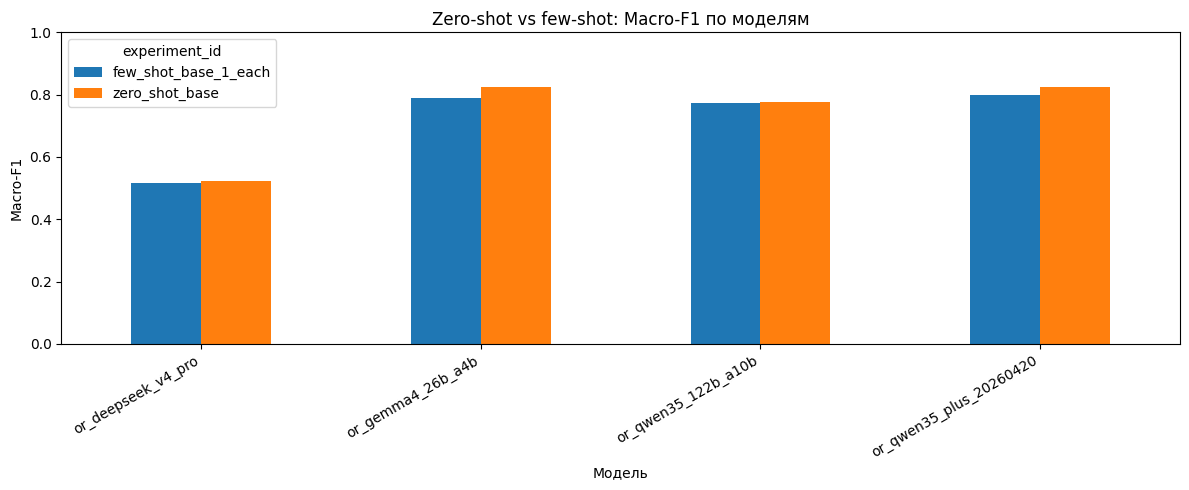

In [76]:
plot_zero_vs_few_all_models(all_models_ablation_summary_df)

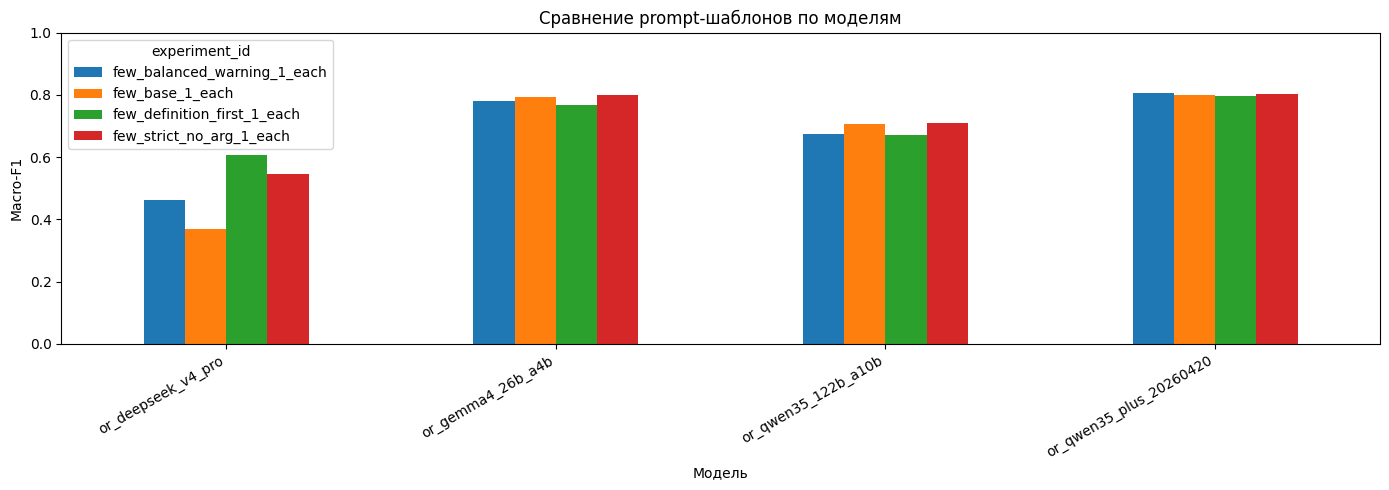

In [77]:
plot_prompt_templates_all_models(all_models_ablation_summary_df)

experiment_id,few_1_1_1,few_1_3_1_noarg_boost,few_1_5_1_noarg_boost
model,,,
or_deepseek_v4_pro,0.4902,0.4848,0.6612
or_gemma4_26b_a4b,0.6916,0.7207,0.7627
or_kimi_k26,NaN,NaN,0.4235
or_qwen35_122b_a10b,0.6711,0.6587,0.6279
or_qwen35_plus_20260420,0.6972,0.7222,0.7931


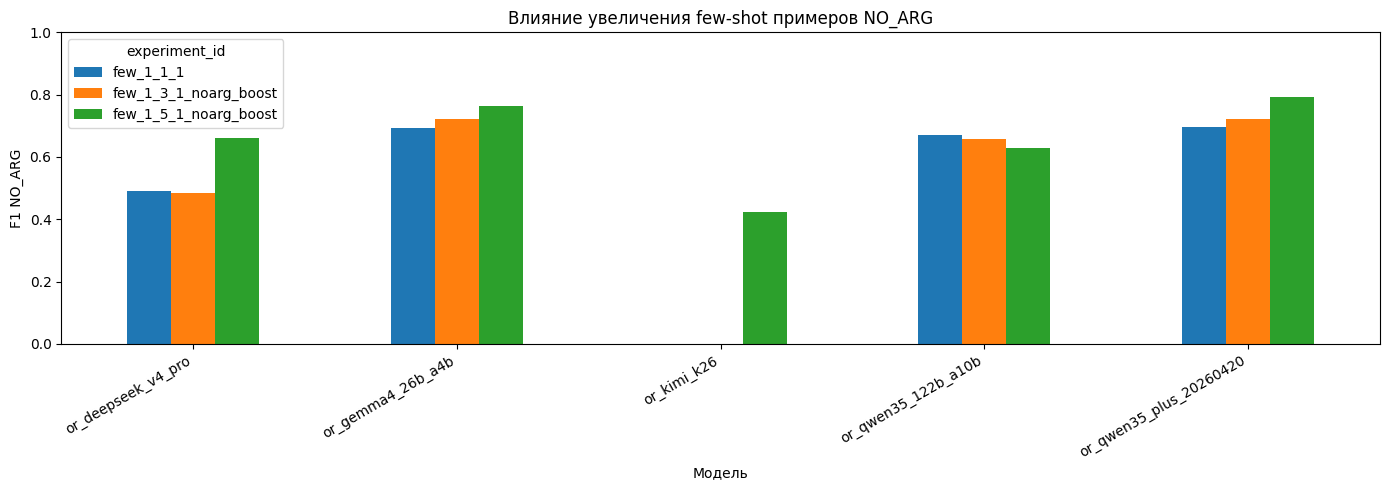

In [78]:
plot_noarg_fewshot_all_models(all_models_ablation_summary_df)

,experiment_id,mean_macro_f1,mean_f1_NO_ARG,mean_f1_AGAINST,mean_f1_FOR,n_valid_models
2,few_1_5_1_noarg_boost,0.678860,0.653680,0.64898,0.785720,5
1,few_1_3_1_noarg_boost,0.703300,0.646600,0.70340,0.773225,4
0,few_1_1_1,0.709675,0.637525,0.71505,0.796725,4


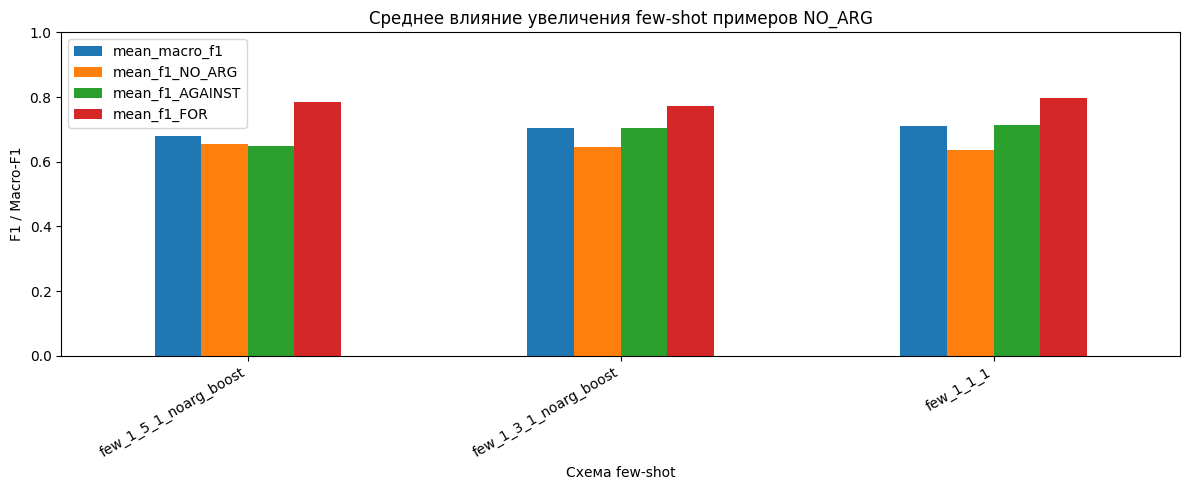

In [79]:
plot_noarg_fewshot_average(all_models_ablation_summary_df)

**Не графики**

In [80]:
def make_sanity_df(eval_df: pd.DataFrame) -> pd.DataFrame:
    return (
        eval_df
        .groupby(["topic", "label"], group_keys=False)
        .head(1)
        .reset_index(drop=True)
    )

In [81]:
def run_sanity_check(model_alias: str, model_id: str) -> pd.DataFrame:
    sanity_df = make_sanity_df(eval_df)

    pred_df = evaluate_openrouter_model(
        model_alias=f"{model_alias}_sanity",
        model_id=model_id,
        train_df=train_df,
        eval_df=sanity_df,
    )

    pred_df["gold_name"] = pred_df["gold"].map(LABEL_ID2NAME)
    pred_df["pred_name"] = pred_df["pred"].map(LABEL_ID2NAME)

    display(
        pred_df[
            [
                "topic",
                "text",
                "gold_name",
                "pred_name",
                "pred_raw",
                "model_id",
            ]
        ]
    )

    print("Диагностика:")
    print(json.dumps(prediction_diagnostics(pred_df), ensure_ascii=False, indent=2))

    return pred_df

In [82]:
def clear_classification_files_for_alias(model_alias: str) -> None:
    safe_alias = safe_filename(model_alias)

    patterns = [
        f"cache_{safe_alias}*.json",
        f"predictions_{safe_alias}*.csv",
        f"metrics_{safe_alias}*.json",
    ]

    for pattern in patterns:
        for path in CLASSIFICATION_DIR.glob(pattern):
            print("Удаляю:", path)
            path.unlink()

In [83]:
def run_classification_models(
    model_runs: list[dict[str, Any]],
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
    run_sanity_first: bool = True,
    max_sanity_fallback: int = 2,
    max_full_fallback_for_valid: int = 30,
    clear_old_for_alias: bool = False,
    stop_on_error: bool = False,
) -> pd.DataFrame:
    run_statuses = []

    for cfg in model_runs:
        alias = cfg["alias"]
        model_id = cfg["model_id"]

        instance_id = None

        print("\n" + "=" * 100)
        print(f"Запуск модели: {alias}")
        print(f"Model id: {model_id}")

        try:
            if clear_old_for_alias:
                clear_classification_files_for_alias(alias)
                clear_classification_files_for_alias(f"{alias}_sanity")

            if USE_AUTO_LOAD_UNLOAD:
                instance_id = load_lmstudio_model(
                    model_id=model_id,
                    context_length=cfg.get("context_length", 4096),
                    flash_attention=cfg.get("flash_attention", True),
                    offload_kv_cache_to_gpu=cfg.get("offload_kv_cache_to_gpu", True),
                    eval_batch_size=cfg.get("eval_batch_size", 512),
                    num_experts=cfg.get("num_experts"),
                    unload_existing=True,
                )
            else:
                print("Автозагрузка не используется для OpenRouter")

            sanity_fallback = None
            sanity_diag = None
            sanity_is_valid = True

            if run_sanity_first:
                print("\nSanity check...")
                sanity_pred = run_sanity_check(alias, model_id)
                sanity_diag = prediction_diagnostics(sanity_pred)
                sanity_fallback = sanity_diag["fallback_count"]

                sanity_is_valid = is_classification_run_valid(
                    sanity_diag,
                    max_fallback=max_sanity_fallback,
                    min_pred_classes=2,
                    max_class_share=0.90,
                )

                if not sanity_is_valid:
                    print(
                        f"Sanity check не пройден: "
                        f"fallback={sanity_diag['fallback_count']}, "
                        f"n_pred_classes={sanity_diag['n_pred_classes']}, "
                        f"max_class_share={sanity_diag['max_class_share']}. "
                        f"Полный прогон модели {alias} пропущен"
                    )

                    run_statuses.append(
                        {
                            "alias": alias,
                            "model_id": model_id,
                            "status": "skipped_after_sanity",
                            "macro_f1_over_topics": None,
                            "accuracy": None,
                            "sanity_fallback_count": sanity_fallback,
                            "fallback_count": None,
                            "repaired_count": None,
                            "direct_retry_count": None,
                            "n_pred_classes": sanity_diag["n_pred_classes"],
                            "max_class_share": sanity_diag["max_class_share"],
                            "pred_distribution": json.dumps(
                                sanity_diag["pred_distribution"],
                                ensure_ascii=False,
                            ),
                            "is_valid": False,
                            "error": None,
                        }
                    )

                    continue

            print("\nПолный прогон...")
            pred_df = evaluate_openrouter_model(
                model_alias=alias,
                model_id=model_id,
                train_df=train_df,
                eval_df=eval_df,
            )

            metrics = calculate_metrics(pred_df)
            save_metrics(alias, metrics)

            diag = prediction_diagnostics(pred_df)

            is_valid = is_classification_run_valid(
                diag,
                max_fallback=max_full_fallback_for_valid,
                min_pred_classes=2,
                max_class_share=0.90,
            )

            run_statuses.append(
                {
                    "alias": alias,
                    "model_id": model_id,
                    "status": "ok",
                    "macro_f1_over_topics": metrics["macro_f1_over_topics"],
                    "accuracy": metrics["accuracy"],
                    "sanity_fallback_count": sanity_fallback,
                    "fallback_count": diag["fallback_count"],
                    "repaired_count": diag["repaired_count"],
                    "direct_retry_count": diag["direct_retry_count"],
                    "n_pred_classes": diag["n_pred_classes"],
                    "max_class_share": diag["max_class_share"],
                    "pred_distribution": json.dumps(
                        diag["pred_distribution"],
                        ensure_ascii=False,
                    ),
                    "is_valid": is_valid,
                    "error": None,
                }
            )

            print("Метрики:")
            print(json.dumps(metrics, ensure_ascii=False, indent=2))

            print("Диагностика:")
            print(json.dumps(diag, ensure_ascii=False, indent=2))

            if not is_valid:
                print(
                    f"Предупреждение: результат модели {alias} невалиден "
                    f"fallback={diag['fallback_count']}, "
                    f"n_pred_classes={diag['n_pred_classes']}, "
                    f"max_class_share={diag['max_class_share']}. "
                    f"!Результат не включать!"
                )

        except Exception as exc:
            print(f"Ошибка на модели {alias}: {exc}")

            run_statuses.append(
                {
                    "alias": alias,
                    "model_id": model_id,
                    "status": "error",
                    "macro_f1_over_topics": None,
                    "accuracy": None,
                    "sanity_fallback_count": None,
                    "fallback_count": None,
                    "repaired_count": None,
                    "direct_retry_count": None,
                    "n_pred_classes": None,
                    "max_class_share": None,
                    "pred_distribution": None,
                    "is_valid": False,
                    "error": str(exc),
                }
            )

            if stop_on_error:
                raise

        finally:
            if USE_AUTO_LOAD_UNLOAD:
                if instance_id is not None:
                    unload_lmstudio_model(instance_id, ignore_errors=True)

                unload_all_llms()
                time.sleep(5)

    status_df = pd.DataFrame(run_statuses)
    status_df.to_csv(
        CLASSIFICATION_DIR / "classification_run_status.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return status_df

In [84]:
classification_status_df = run_classification_models(
    model_runs=MODEL_RUNS,
    train_df=train_df,
    eval_df=eval_df,
    run_sanity_first=True,
    max_sanity_fallback=2,
    max_full_fallback_for_valid=30,
    clear_old_for_alias=False,
    stop_on_error=False,
)


Запуск модели: or_qwen35_plus_20260420
Model id: qwen/qwen3.5-plus-20260420
Автозагрузка не используется для OpenRouter

Sanity check...
Alias: or_qwen35_plus_20260420_sanity
OpenRouter model_id: qwen/qwen3.5-plus-20260420


Evaluating or_qwen35_plus_20260420_sanity:   0%|          | 0/9 [00:00<?, ?it/s]

,topic,text,gold_name,pred_name,pred_raw,model_id
0,vaccines,Вдобавок иммунитет в результате выздоровления ...,FOR,FOR,LABEL_ID=2\nThe user wants me to classify a te...,qwen/qwen3.5-plus-20260420
1,masks,"[USER], из-за того что много не выявленных бол...",FOR,FOR,LABEL_ID=2\nThe user wants me to classify a te...,qwen/qwen3.5-plus-20260420
2,masks,"[USER], Само название —-МЕДИЦИНСКАЯ МАСКА---го...",AGAINST,AGAINST,LABEL_ID=0\nThe user wants me to classify a te...,qwen/qwen3.5-plus-20260420
3,quarantine,"где народ митингует, там странным образом кара...",AGAINST,AGAINST,LABEL_ID=0\nThe user wants me to classify a te...,qwen/qwen3.5-plus-20260420
4,vaccines,"[USER], И Спида не существует, а прививки прид...",AGAINST,AGAINST,LABEL_ID=0\nThe user wants me to classify a te...,qwen/qwen3.5-plus-20260420
5,quarantine,А если ты привёз вирус домой и не прошёл каран...,FOR,FOR,LABEL_ID=2\nThe user wants me to classify a te...,qwen/qwen3.5-plus-20260420
6,masks,"Никому больше носить маску не нужно, и тому ес...",NO_ARG,AGAINST,LABEL_ID=0\nThe user wants me to classify a te...,qwen/qwen3.5-plus-20260420
7,quarantine,"Пенсионерам, которые сейчас сидят на карантине...",NO_ARG,NO_ARG,LABEL_ID=1\nThe user wants me to classify a te...,qwen/qwen3.5-plus-20260420
8,vaccines,Лучше бы деньги на создание вакцины дали!,NO_ARG,FOR,LABEL_ID=2\nThe user wants me to classify a te...,qwen/qwen3.5-plus-20260420


Диагностика:
{
  "n": 9,
  "pred_distribution": {
    "FOR": 4,
    "AGAINST": 4,
    "NO_ARG": 1
  },
  "n_pred_classes": 3,
  "max_class_share": 0.4444,
  "fallback_count": 0,
  "repaired_count": 0,
  "direct_retry_count": 0
}

Полный прогон...
Alias: or_qwen35_plus_20260420
OpenRouter model_id: qwen/qwen3.5-plus-20260420


Evaluating or_qwen35_plus_20260420:   0%|          | 0/450 [00:00<?, ?it/s]

...

Evaluating or_gemma4_26b_a4b_sanity:   0%|          | 0/9 [00:00<?, ?it/s]

,topic,text,gold_name,pred_name,pred_raw,model_id
0,vaccines,Вдобавок иммунитет в результате выздоровления ...,FOR,FOR,LABEL_ID=2,google/gemma-4-26b-a4b-it
1,masks,"[USER], из-за того что много не выявленных бол...",FOR,FOR,LABEL_ID=2,google/gemma-4-26b-a4b-it
2,masks,"[USER], Само название —-МЕДИЦИНСКАЯ МАСКА---го...",AGAINST,AGAINST,LABEL_ID=0,google/gemma-4-26b-a4b-it
3,quarantine,"где народ митингует, там странным образом кара...",AGAINST,AGAINST,LABEL_ID=0,google/gemma-4-26b-a4b-it
4,vaccines,"[USER], И Спида не существует, а прививки прид...",AGAINST,AGAINST,LABEL_ID=0,google/gemma-4-26b-a4b-it
5,quarantine,А если ты привёз вирус домой и не прошёл каран...,FOR,AGAINST,LABEL_ID=0,google/gemma-4-26b-a4b-it
6,masks,"Никому больше носить маску не нужно, и тому ес...",NO_ARG,AGAINST,LABEL_ID=0,google/gemma-4-26b-a4b-it
7,quarantine,"Пенсионерам, которые сейчас сидят на карантине...",NO_ARG,NO_ARG,LABEL_ID=1,google/gemma-4-26b-a4b-it
8,vaccines,Лучше бы деньги на создание вакцины дали!,NO_ARG,NO_ARG,LABEL_ID=1,google/gemma-4-26b-a4b-it


Диагностика:
{
  "n": 9,
  "pred_distribution": {
    "AGAINST": 5,
    "FOR": 2,
    "NO_ARG": 2
  },
  "n_pred_classes": 3,
  "max_class_share": 0.5556,
  "fallback_count": 0,
  "repaired_count": 0,
  "direct_retry_count": 0
}

Полный прогон...
Alias: or_gemma4_26b_a4b
OpenRouter model_id: google/gemma-4-26b-a4b-it


Evaluating or_gemma4_26b_a4b:   0%|          | 0/450 [00:00<?, ?it/s]

Метрики:
{
  "macro_f1_over_topics": 0.7747,
  "accuracy": 0.78,
  "per_topic": {
    "masks": {
      "macro_f1": 0.8326,
      "n_examples": 150
    },
    "quarantine": {
      "macro_f1": 0.7561,
      "n_examples": 150
    },
    "vaccines": {
      "macro_f1": 0.7354,
      "n_examples": 150
    }
  },
  "overall_report": {
    "AGAINST": {
      "precision": 0.6831683168316832,
      "recall": 0.92,
      "f1-score": 0.7840909090909091,
      "support": 150.0
    },
    "NO_ARG": {
      "precision": 0.8317757009345794,
      "recall": 0.5933333333333334,
      "f1-score": 0.6926070038910506,
      "support": 150.0
    },
    "FOR": {
      "precision": 0.8794326241134752,
      "recall": 0.8266666666666667,
      "f1-score": 0.852233676975945,
      "support": 150.0
    },
    "accuracy": 0.78,
    "macro avg": {
      "precision": 0.7981255472932459,
      "recall": 0.7799999999999999,
      "f1-score": 0.7763105299859682,
      "support": 450.0
    },
    "weighted avg": {
  

In [85]:
display(classification_status_df)

,alias,model_id,status,macro_f1_over_topics,accuracy,sanity_fallback_count,fallback_count,repaired_count,direct_retry_count,n_pred_classes,max_class_share,pred_distribution,is_valid,error
0,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,ok,0.7963,0.8044,0,0.0,0.0,0.0,3,0.3933,"{""AGAINST"": 177, ""FOR"": 164, ""NO_ARG"": 109}",True,None
1,or_qwen35_122b_a10b,qwen/qwen3.5-122b-a10b,ok,0.7259,0.7267,0,0.0,0.0,0.0,3,0.3844,"{""AGAINST"": 173, ""NO_ARG"": 157, ""FOR"": 120}",True,None
2,or_kimi_k26,moonshotai/kimi-k2.6,skipped_after_sanity,NaN,NaN,0,NaN,NaN,NaN,1,1.0000,"{""FOR"": 9}",False,None
3,or_deepseek_v4_pro,deepseek/deepseek-v4-pro,ok,0.5808,0.6022,1,19.0,28.0,13.0,3,0.4978,"{""FOR"": 224, ""AGAINST"": 132, ""NO_ARG"": 94}",True,None
4,or_gemma4_26b_a4b,google/gemma-4-26b-a4b-it,ok,0.7747,0.7800,0,0.0,0.0,0.0,3,0.4489,"{""AGAINST"": 202, ""FOR"": 141, ""NO_ARG"": 107}",True,None


In [86]:
all_metrics = load_all_metrics()
classification_summary_df = make_classification_summary_df(all_metrics)

In [87]:
display(classification_summary_df)

,model,macro_f1_over_topics,accuracy,masks_f1,quarantine_f1,vaccines_f1,f1_AGAINST,f1_NO_ARG,f1_FOR
0,or_qwen35_plus_20260420,0.7963,0.8044,0.8104,0.7841,0.7943,0.8502,0.6873,0.8535
1,or_gemma4_26b_a4b,0.7747,0.7800,0.8326,0.7561,0.7354,0.7841,0.6926,0.8522
2,or_qwen35_122b_a10b,0.7259,0.7267,0.7615,0.6907,0.7254,0.8050,0.6254,0.7481
3,or_deepseek_v4_pro,0.5808,0.6022,0.8137,0.6596,0.2690,0.6028,0.5656,0.6257


In [88]:
classification_status_df = pd.read_csv(
    CLASSIFICATION_DIR / "classification_run_status.csv"
)

classification_summary_df = pd.read_csv(
    CLASSIFICATION_DIR / "classification_summary.csv"
)

valid_aliases = classification_status_df.loc[
    classification_status_df["is_valid"] == True,
    "alias"
].tolist()

valid_classification_summary_df = classification_summary_df[
    classification_summary_df["model"].isin(valid_aliases)
].copy()

display(valid_classification_summary_df)

valid_classification_summary_df.to_csv(
    CLASSIFICATION_DIR / "classification_summary_valid_only.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,macro_f1_over_topics,accuracy,masks_f1,quarantine_f1,vaccines_f1,f1_AGAINST,f1_NO_ARG,f1_FOR
0,or_qwen35_plus_20260420,0.7963,0.8044,0.8104,0.7841,0.7943,0.8502,0.6873,0.8535
1,or_gemma4_26b_a4b,0.7747,0.7800,0.8326,0.7561,0.7354,0.7841,0.6926,0.8522
2,or_qwen35_122b_a10b,0.7259,0.7267,0.7615,0.6907,0.7254,0.8050,0.6254,0.7481
3,or_deepseek_v4_pro,0.5808,0.6022,0.8137,0.6596,0.2690,0.6028,0.5656,0.6257


In [89]:
def plot_classification_summary(summary_df: pd.DataFrame) -> None:
    if summary_df.empty:
        print("Нет данных для графика.")
        return

    plot_df = summary_df.set_index("model")[
        [
            "macro_f1_over_topics",
            "accuracy",
        ]
    ]

    plot_df.plot(kind="bar", figsize=(11, 5))

    plt.title("Сравнение моделей по качеству классификации аргументов")
    plt.xlabel("Модель")
    plt.ylabel("Значение метрики")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        CLASSIFICATION_DIR / "classification_summary.png",
        dpi=200,
    )

    plt.show()

In [90]:
def plot_topic_f1(summary_df: pd.DataFrame) -> None:
    if summary_df.empty:
        print("Нет данных для графика.")
        return

    plot_df = summary_df.set_index("model")[
        [
            "masks_f1",
            "quarantine_f1",
            "vaccines_f1",
        ]
    ]

    plot_df.plot(kind="bar", figsize=(12, 5))

    plt.title("Macro-F1 моделей по темам")
    plt.xlabel("Модель")
    plt.ylabel("Macro-F1")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        CLASSIFICATION_DIR / "classification_topic_f1.png",
        dpi=200,
    )

    plt.show()

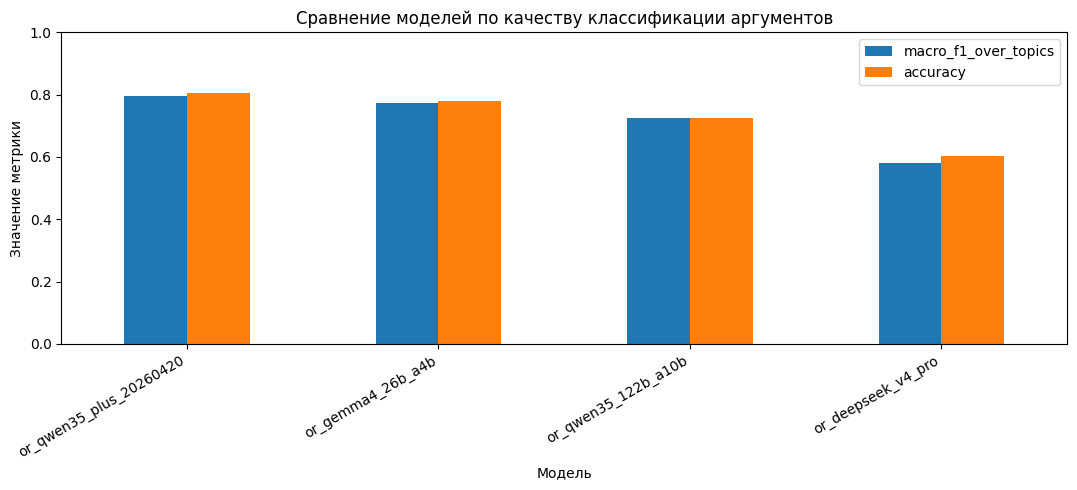

In [91]:
plot_classification_summary(classification_summary_df)

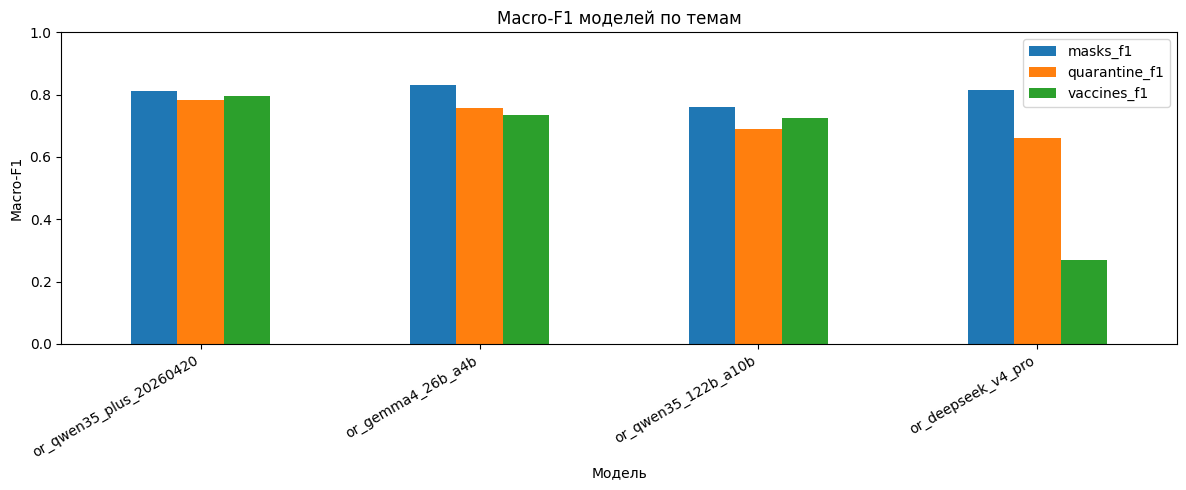

In [92]:
plot_topic_f1(classification_summary_df)

In [93]:
def load_predictions(model_alias: str) -> pd.DataFrame:
    path = predictions_path_for(model_alias)

    if not path.exists():
        raise FileNotFoundError(f"Не найден файл: {path}")

    return pd.read_csv(path)

In [94]:
def analyze_best_classification_model(
    summary_df: pd.DataFrame,
    status_df: Optional[pd.DataFrame] = None,
) -> None:
    if summary_df.empty:
        print("Нет summary_df.")
        return

    candidate_df = summary_df.copy()

    if status_df is not None and not status_df.empty and "is_valid" in status_df.columns:
        valid_models = set(status_df.loc[status_df["is_valid"] == True, "alias"].tolist())
        candidate_df = candidate_df[candidate_df["model"].isin(valid_models)]

    if candidate_df.empty:
        print("Нет валидных моделей для анализа.")
        return

    best_model = candidate_df.iloc[0]["model"]
    print("Лучшая валидная модель:", best_model)

    pred_df = load_predictions(best_model)

    cm = confusion_matrix(
        pred_df["gold"],
        pred_df["pred"],
        labels=[0, 1, 2],
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[LABEL_ID2NAME[i] for i in [0, 1, 2]],
    )

    disp.plot(values_format="d")
    plt.title(f"Матрица ошибок: {best_model}")
    plt.tight_layout()

    plt.savefig(
        CLASSIFICATION_DIR / f"confusion_matrix_{safe_filename(best_model)}.png",
        dpi=200,
    )

    plt.show()

    pred_df["gold_name"] = pred_df["gold"].map(LABEL_ID2NAME)
    pred_df["pred_name"] = pred_df["pred"].map(LABEL_ID2NAME)

    errors_df = pred_df[pred_df["gold"] != pred_df["pred"]].copy()

    error_types = (
        errors_df
        .groupby(["topic", "gold_name", "pred_name"])
        .size()
        .reset_index(name="error_count")
        .sort_values("error_count", ascending=False)
    )

    print("Типы ошибок:")
    display(error_types)

    print("Примеры ошибок:")
    display(
        errors_df[
            [
                "topic",
                "thesis",
                "text",
                "gold_name",
                "pred_name",
                "pred_raw",
            ]
        ].head(20)
    )

Лучшая валидная модель: or_qwen35_plus_20260420


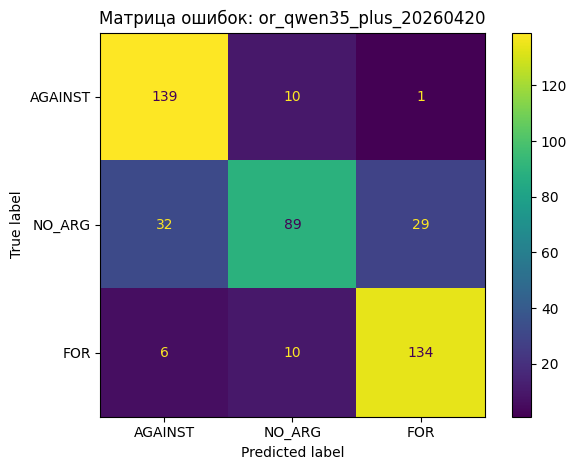

Типы ошибок:


,topic,gold_name,pred_name,error_count
9,quarantine,NO_ARG,FOR,14
14,vaccines,NO_ARG,AGAINST,14
8,quarantine,NO_ARG,AGAINST,11
4,masks,NO_ARG,FOR,9
3,masks,NO_ARG,AGAINST,7
2,masks,FOR,NO_ARG,6
15,vaccines,NO_ARG,FOR,6
11,vaccines,AGAINST,NO_ARG,5
0,masks,AGAINST,NO_ARG,4
1,masks,FOR,AGAINST,2


Примеры ошибок:


,topic,thesis,text,gold_name,pred_name,pred_raw
12,masks,Ношение масок полезно для общества.,"Никому больше носить маску не нужно, и тому ес...",NO_ARG,AGAINST,LABEL_ID=0\nThe user wants me to classify a te...
17,masks,Ношение масок полезно для общества.,"да маски платные, но есть еще места где их мож...",NO_ARG,FOR,LABEL_ID=2\nThe user wants me to classify a te...
29,quarantine,Введение и соблюдение карантина полезно для об...,Москва первой начала вводить карантинные огран...,NO_ARG,FOR,LABEL_ID=2\nThe user wants me to classify a te...
30,quarantine,Введение и соблюдение карантина полезно для об...,"Итак, вирус уже распространяется в РФ с геомет...",NO_ARG,FOR,LABEL_ID=2\nThe user wants me to classify a te...
35,vaccines,Вакцинация полезна для общества.,"[USER], если прививка будет как от гриппа, то ...",NO_ARG,AGAINST,LABEL_ID=0\nThe user wants me to classify a te...
38,masks,Ношение масок полезно для общества.,"Я также считаю лучшей мерой, меньше находиться...",NO_ARG,AGAINST,LABEL_ID=0\nThe user wants me to classify a te...
46,quarantine,Введение и соблюдение карантина полезно для об...,А вы хотите чтобы люди в количестве 300 челове...,NO_ARG,FOR,LABEL_ID=2\nThe user wants me to classify a te...
48,vaccines,Вакцинация полезна для общества.,Производители вакцин зарабатывают на пандемиях...,NO_ARG,AGAINST,LABEL_ID=0\nThe user wants me to classify a te...
58,masks,Ношение масок полезно для общества.,"[USER], защищает или нет, никто не хочет на се...",FOR,NO_ARG,LABEL_ID=1\nThe user wants me to classify a te...
64,masks,Ношение масок полезно для общества.,маски не спасают нужны респираторы медицинские,NO_ARG,AGAINST,LABEL_ID=0\nThe user wants me to classify a te...


In [95]:
analyze_best_classification_model(classification_summary_df, classification_status_df)

In [96]:
STANCE2RU = {
    "FOR": "в поддержку тезиса",
    "AGAINST": "против тезиса",
}

GENERATION_VARIANTS = [
    "Сделай акцент на причинно-следственной связи.",
    "Используй бытовой или общественный пример, но не выдумывай статистику.",
    "Сформулируй аргумент в нейтральном научно-популярном стиле.",
    "Сделай аргумент кратким и логически последовательным.",
    "Добавь объяснение, почему позиция может быть полезна или вредна для общества.",
]

In [97]:
def make_generation_tasks(
    n_per_topic_stance: int = N_GENERATION_PER_TOPIC_STANCE,
    save_path: Path = GENERATION_DIR / "generation_tasks.csv",
) -> pd.DataFrame:
    rows = []

    for topic, thesis in TOPIC2THESIS.items():
        for stance in ["FOR", "AGAINST"]:
            for i in range(n_per_topic_stance):
                task_id = f"{topic}__{stance}__{i:03d}"
                variant = GENERATION_VARIANTS[i % len(GENERATION_VARIANTS)]

                rows.append(
                    {
                        "task_id": task_id,
                        "topic": topic,
                        "thesis": thesis,
                        "stance": stance,
                        "stance_ru": STANCE2RU[stance],
                        "variant_id": i % len(GENERATION_VARIANTS),
                        "generation_instruction": variant,
                    }
                )

    df = pd.DataFrame(rows)
    df.to_csv(save_path, index=False, encoding="utf-8-sig")
    return df

In [98]:
generation_tasks_df = make_generation_tasks()

display(generation_tasks_df.head())

,task_id,topic,thesis,stance,stance_ru,variant_id,generation_instruction
0,masks__FOR__000,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,0,Сделай акцент на причинно-следственной связи.
1,masks__FOR__001,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,1,"Используй бытовой или общественный пример, но ..."
2,masks__FOR__002,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,2,Сформулируй аргумент в нейтральном научно-попу...
3,masks__FOR__003,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,3,Сделай аргумент кратким и логически последоват...
4,masks__FOR__004,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,4,"Добавь объяснение, почему позиция может быть п..."


In [99]:
print("Всего заданий:", len(generation_tasks_df))

Всего заданий: 120


In [100]:
def build_generation_messages(row: pd.Series) -> list[dict[str, str]]:
  system_prompt = (
      "/no_think\n"
      "Ты генерируешь аргументы на русском языке. "
      "Нужно создать один короткий аргумент по заданному тезису и позиции. "
      "Не используй reasoning-блоки, теги <think>, markdown, списки или пояснения. "
      "Не выдумывай конкретные статистические данные, названия исследований или ссылки. "
      "Отвечай только самим аргументом."
  )

  user_prompt = f"""
    Тезис: {row["thesis"]}
    Требуемая позиция: {row["stance"]} — {row["stance_ru"]}.

    Дополнительное требование: {row["generation_instruction"]}

    Сгенерируй один краткий аргумент, который:
    1) соответствует заданной позиции;
    2) содержит причину, следствие, пример или объяснение;
    3) не является простым эмоциональным мнением;
    4) состоит из 1–3 предложений.

    Не используй теги <think> или рассуждения.
    Верни только готовый аргумент.

    Аргумент:""".strip()

  return [{"role": "system", "content": system_prompt},
          {"role": "user", "content": user_prompt},]

In [101]:
def clean_generated_argument(text: str) -> str:
    text = remove_thinking_blocks(text)
    text = str(text).strip()

    # Удаляем markdown code fences
    text = re.sub(r"^```[a-zA-Zа-яА-Я0-9_-]*", "", text).strip()
    text = re.sub(r"```$", "", text).strip()

    # Удаляем типичные заголовки
    text = re.sub(
        r"^(Ответ|Аргумент|Сгенерированный аргумент)\s*:\s*",
        "",
        text,
        flags=re.I,
    ).strip()

    # Если модель вывела Thinking Process, пытаемся оставить только финальную часть
    patterns = [
        r"(?i)final answer\s*:\s*(.*)",
        r"(?i)final argument\s*:\s*(.*)",
        r"(?i)argument\s*:\s*(.*)",
        r"(?i)итоговый аргумент\s*:\s*(.*)",
        r"(?i)аргумент\s*:\s*(.*)",
    ]

    for pattern in patterns:
        match = re.search(pattern, text, flags=re.S)
        if match:
            text = match.group(1).strip()
            break

    # Если в конце идет англоязычная инструкция типа Need a short argument..., отрезаем ее
    text = re.split(
        r"(?i)\bNeed a short argument\b|\bWe need\b|\bThe user asks\b|\bNow craft\b",
        text,
        maxsplit=1,
    )[0].strip()

    # Убираем строки-списки
    lines = [line.strip(" -•\t") for line in text.splitlines() if line.strip()]
    text = " ".join(lines)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [102]:
def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()

In [103]:
def save_df(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8-sig")

In [104]:
def run_generation_for_model(
    model_alias: str,
    model_id: str,
    tasks_df: pd.DataFrame,
    output_path: Path = GENERATION_DIR / "generated_arguments.csv",
    temperature: float = 0.7,
    top_p: float = 0.9,
    max_tokens: int = 180,
    request_pause: float = 0.2,
) -> pd.DataFrame:
    actual_model_id = resolve_model_id(model_id)

    print("Generation alias:", model_alias)
    print("OpenRouter model_id:", actual_model_id)

    generated_df = read_csv_if_exists(output_path)

    done_ids = set()
    if not generated_df.empty:
        done_ids = set(generated_df["argument_id"].astype(str).tolist())

    records = []

    for _, row in tqdm(tasks_df.iterrows(), total=len(tasks_df), desc=f"Generation: {model_alias}"):
        argument_id = f"{model_alias}__{row['task_id']}"

        if argument_id in done_ids:
            continue

        messages = build_generation_messages(row)

        raw = chat_complete_model(
            messages=messages,
            model_id=actual_model_id,
            temperature=temperature,
            top_p=top_p,
            max_tokens=max_tokens,
        )

        argument = clean_generated_argument(raw)

        records.append(
            {
                "argument_id": argument_id,
                "model_alias": model_alias,
                "model_id": actual_model_id,
                "task_id": row["task_id"],
                "topic": row["topic"],
                "thesis": row["thesis"],
                "stance": row["stance"],
                "stance_ru": row["stance_ru"],
                "generation_instruction": row["generation_instruction"],
                "generated_argument": argument,
                "raw_generation": raw,
            }
        )

        if len(records) % 5 == 0:
            new_df = pd.DataFrame(records)
            generated_df = pd.concat([generated_df, new_df], ignore_index=True)
            generated_df = generated_df.drop_duplicates(subset=["argument_id"], keep="last")
            save_df(generated_df, output_path)
            records = []

        time.sleep(request_pause)

    if records:
        new_df = pd.DataFrame(records)
        generated_df = pd.concat([generated_df, new_df], ignore_index=True)
        generated_df = generated_df.drop_duplicates(subset=["argument_id"], keep="last")
        save_df(generated_df, output_path)

    return generated_df

In [105]:
GENERATION_MODEL_RUNS = MODEL_RUNS.copy()

In [106]:
def run_generation_models(
    model_runs: list[dict[str, Any]],
    tasks_df: pd.DataFrame,
    stop_on_error: bool = False,
) -> pd.DataFrame:
    statuses = []

    for cfg in model_runs:
        alias = cfg["alias"]
        model_id = cfg["model_id"]
        instance_id = None

        print("\n" + "=" * 100)
        print("Генерация:", alias)

        try:
            if USE_AUTO_LOAD_UNLOAD:
                instance_id = load_lmstudio_model(
                    model_id=model_id,
                    context_length=cfg.get("context_length", 4096),
                    flash_attention=cfg.get("flash_attention", True),
                    offload_kv_cache_to_gpu=cfg.get("offload_kv_cache_to_gpu", True),
                    eval_batch_size=cfg.get("eval_batch_size", 512),
                    num_experts=cfg.get("num_experts"),
                    unload_existing=True,
                )
            else:
                print("Автозагрузка не используется для OpenRouter.")

            before_df = read_csv_if_exists(GENERATION_DIR / "generated_arguments.csv")
            before_n = len(before_df)

            generated_df = run_generation_for_model(
                model_alias=alias,
                model_id=model_id,
                tasks_df=tasks_df,
                temperature=0.7,
                top_p=0.9,
                max_tokens=180,
            )

            after_n = len(generated_df)

            statuses.append(
                {
                    "alias": alias,
                    "model_id": model_id,
                    "status": "ok",
                    "generated_new": int(after_n - before_n),
                    "total_generated": int(after_n),
                    "error": None,
                }
            )

        except Exception as exc:
            print("Ошибка генерации:", exc)

            statuses.append(
                {
                    "alias": alias,
                    "model_id": model_id,
                    "status": "error",
                    "generated_new": None,
                    "total_generated": None,
                    "error": str(exc),
                }
            )

            if stop_on_error:
                raise

        finally:
            if USE_AUTO_LOAD_UNLOAD:
                if instance_id is not None:
                    unload_lmstudio_model(instance_id, ignore_errors=True)
                unload_all_llms()
                time.sleep(5)

    status_df = pd.DataFrame(statuses)
    status_df.to_csv(
        GENERATION_DIR / "generation_run_status.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return status_df

In [107]:
generation_status_df = run_generation_models(
    model_runs=GENERATION_MODEL_RUNS,
    tasks_df=generation_tasks_df,
    stop_on_error=False,
)


Генерация: or_qwen35_plus_20260420
Автозагрузка не используется для OpenRouter.
Generation alias: or_qwen35_plus_20260420
OpenRouter model_id: qwen/qwen3.5-plus-20260420


Generation: or_qwen35_plus_20260420:   0%|          | 0/120 [00:00<?, ?it/s]


Генерация: or_qwen35_122b_a10b
Автозагрузка не используется для OpenRouter.
Generation alias: or_qwen35_122b_a10b
OpenRouter model_id: qwen/qwen3.5-122b-a10b


Generation: or_qwen35_122b_a10b:   0%|          | 0/120 [00:00<?, ?it/s]


Генерация: or_kimi_k26
Автозагрузка не используется для OpenRouter.
Generation alias: or_kimi_k26
OpenRouter model_id: moonshotai/kimi-k2.6


Generation: or_kimi_k26:   0%|          | 0/120 [00:00<?, ?it/s]


Генерация: or_deepseek_v4_pro
Автозагрузка не используется для OpenRouter.
Generation alias: or_deepseek_v4_pro
OpenRouter model_id: deepseek/deepseek-v4-pro


Generation: or_deepseek_v4_pro:   0%|          | 0/120 [00:00<?, ?it/s]


Генерация: or_gemma4_26b_a4b
Автозагрузка не используется для OpenRouter.
Generation alias: or_gemma4_26b_a4b
OpenRouter model_id: google/gemma-4-26b-a4b-it


Generation: or_gemma4_26b_a4b:   0%|          | 0/120 [00:00<?, ?it/s]

In [108]:
display(generation_status_df)

,alias,model_id,status,generated_new,total_generated,error
0,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,ok,120,120,None
1,or_qwen35_122b_a10b,qwen/qwen3.5-122b-a10b,ok,120,240,None
2,or_kimi_k26,moonshotai/kimi-k2.6,ok,120,360,None
3,or_deepseek_v4_pro,deepseek/deepseek-v4-pro,ok,120,480,None
4,or_gemma4_26b_a4b,google/gemma-4-26b-a4b-it,ok,120,600,None


In [109]:
generated_df = pd.read_csv(GENERATION_DIR / "generated_arguments.csv")
display(generated_df.head())

,argument_id,model_alias,model_id,task_id,topic,thesis,stance,stance_ru,generation_instruction,generated_argument,raw_generation
0,or_qwen35_plus_20260420__masks__FOR__000,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,masks__FOR__000,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,Сделай акцент на причинно-следственной связи.,** * *Idea:* Masks block droplets -> fewer peo...,Поскольку маски создают физический барьер для ...
1,or_qwen35_plus_20260420__masks__FOR__001,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,masks__FOR__001,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,"Используй бытовой или общественный пример, но ...",** * *Idea:* Masks prevent the spread of dropl...,Ношение масок в общественном транспорте снижае...
2,or_qwen35_plus_20260420__masks__FOR__002,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,masks__FOR__002,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,Сформулируй аргумент в нейтральном научно-попу...,** * *Idea:* Masks filter respiratory droplets...,"Использование масок создает физический барьер,..."
3,or_qwen35_plus_20260420__masks__FOR__003,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,masks__FOR__003,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,Сделай аргумент кратким и логически последоват...,"Ношение масок создает физический барьер, котор...","Ношение масок создает физический барьер, котор..."
4,or_qwen35_plus_20260420__masks__FOR__004,or_qwen35_plus_20260420,qwen/qwen3.5-plus-20260420,masks__FOR__004,masks,Ношение масок полезно для общества.,FOR,в поддержку тезиса,"Добавь объяснение, почему позиция может быть п...",** * *Idea:* Masks reduce transmission of resp...,Ношение масок снижает риск передачи респиратор...


In [110]:
print("Всего сгенерировано:", len(generated_df))

Всего сгенерировано: 600


In [111]:
def generation_artifact_diagnostics(generated_df: pd.DataFrame) -> pd.DataFrame:
    df = generated_df.copy()

    text = df["generated_argument"].astype(str)

    df["empty"] = text.str.strip().eq("")
    df["too_short"] = text.str.len() < 30

    df["has_english_markers"] = text.str.contains(
        r"\bThesis\b|\bArgument\b|\bClaim\b|\bStance\b|\bFOR\b|\bAGAINST\b|"
        r"\bThinking Process\b|\bNeed a short argument\b|\bWe need\b|\bThe user asks\b",
        regex=True,
        case=False,
    )

    df["has_markdown_bullets"] = text.str.contains(
        r"^\s*[\*\-\•]",
        regex=True,
    )

    df["has_prompt_echo"] = text.str.contains(
        r"Тезис:|Требуемая позиция:|Аргумент:",
        regex=True,
        case=False,
    )

    df["has_reasoning_text"] = text.str.contains(
        r"Хм, пользователь|Давай подумаем|пользователь просит|"
        r"Thinking Process|Analyze the Request|Let's craft|Need a short argument",
        regex=True,
        case=False,
    )

    artifact_cols = [
        "empty",
        "too_short",
        "has_english_markers",
        "has_markdown_bullets",
        "has_prompt_echo",
        "has_reasoning_text",
    ]

    df["has_any_artifact"] = df[artifact_cols].any(axis=1)

    summary = (
        df
        .groupby("model_alias")
        .agg(
            n=("argument_id", "count"),
            empty=("empty", "sum"),
            too_short=("too_short", "sum"),
            english_markers=("has_english_markers", "sum"),
            markdown_bullets=("has_markdown_bullets", "sum"),
            prompt_echo=("has_prompt_echo", "sum"),
            reasoning_text=("has_reasoning_text", "sum"),
            artifact_examples=("has_any_artifact", "sum"),
        )
        .reset_index()
    )

    summary["artifact_share"] = (
        summary["artifact_examples"] / summary["n"]
    ).round(3)

    return summary

In [112]:
generated_df = pd.read_csv(GENERATION_DIR / "generated_arguments.csv")

artifact_summary = generation_artifact_diagnostics(generated_df)

display(artifact_summary)

artifact_summary.to_csv(
    GENERATION_DIR / "generation_artifact_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,model_alias,n,empty,too_short,english_markers,markdown_bullets,prompt_echo,reasoning_text,artifact_examples,artifact_share
0,or_deepseek_v4_pro,120,0,0,75,0,54,5,95,0.792
1,or_gemma4_26b_a4b,120,0,0,0,0,0,0,0,0.000
2,or_kimi_k26,120,0,0,120,0,0,25,120,1.000
3,or_qwen35_122b_a10b,120,0,0,120,71,40,120,120,1.000
4,or_qwen35_plus_20260420,120,0,0,120,26,32,120,120,1.000


In [113]:
archive_base = str(RESULTS_DIR)
archive_path = shutil.make_archive(archive_base, "zip", RESULTS_DIR)

print("Архив с результатами облачного эксперимента создан:", archive_path)


Архив с результатами облачного эксперимента создан: C:\Windows\System32\results_vkr_openrouter_experiment.zip
